# Predictive Maintenance for Ball Bearings
## CNN-Based Remaining Useful Life Prediction on FEMTO Data
### A CRISP-DM Approach

---

| | |
|---|---|
| **Project**     | Mini Project 2 — Predictive Maintenance: Bearing RUL Prediction |
| **Dataset**      | FEMTO / PRONOSTIA (IEEE PHM 2012 Challenge) |
| **Source**       | FEMTO-ST Institute, Besançon, France |
| **Methodology**  | CRISP-DM |
| **Supervised by**| Prof. Felix Georg Müller |
| **Created by**   | Sravanthi |
| **Course**       | M.Sc. Industrial AI |
| **Institute**    | Hochschule Albstadt-Sigmaringen |

In [1]:
"""
=============================================================================
CRISP-DM Phase 1 & 2: Business Understanding + Environment Setup
=============================================================================
Project   : Predictive Maintenance — Bearing RUL Prediction
Dataset   : FEMTO / PRONOSTIA (IEEE PHM 2012 Challenge)
Source    : FEMTO-ST Institute, Besançon, France

Business Problem
----------------
Ball bearing failures are the primary cause of unplanned downtime on
production lines with heavily loaded electric motors. Each failure causes:
  - Production delays and missed delivery windows
  - Emergency repair costs (labour + parts)
  - Potential safety incidents

Business Goal (for a production engineer, not a data scientist)
---------------------------------------------------------------
Answer three questions in real time for any bearing on the line:
  1. How many hours until this bearing needs replacing?      → RUL (hours)
  2. Is it healthy, degrading, or about to fail?             → 4-class badge
  3. How confident are we in that estimate?                  → ± uncertainty band

Data Mining Goal
----------------
  - Regression     : predict RUL (hours) from vibration windows
  - Classification : assign one of 4 health stages from the HI curve
  - Uncertainty    : provide a confidence band on the RUL estimate

Signal note (from dataset spec)
--------------------------------
  Every 10 seconds, a 0.1 s burst is recorded at 25.6 kHz
  → 2560 samples per window, one window per 10 s timestep.
  Temperature channels exist for some bearings only → excluded for
  consistency across all bearings (standard practice in literature).
  Torque signal not present in FEMTO dataset → excluded.

References
----------
  Cheng, Ma et al. 2018 — CNN + SVR degradation indicator (primary model)
  Sutrisno, Oh et al. 2012 — Kurtosis + Bayesian Monte Carlo baseline
=============================================================================
"""

# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import warnings
from pathlib import Path

# ---------------------------------------------------------------------------
# Numerical / data
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew

# ---------------------------------------------------------------------------
# Machine learning
# ---------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.decomposition import PCA

# ---------------------------------------------------------------------------
# Deep learning
# ---------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ---------------------------------------------------------------------------
# rul-datasets (FEMTO DataModule)
# ---------------------------------------------------------------------------
import rul_datasets
from rul_datasets.reader import FemtoReader  # noqa: F401

# ---------------------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import itertools

# ---------------------------------------------------------------------------
# Global settings
# ---------------------------------------------------------------------------
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Colour palette (project standard)
C_PRIMARY = "royalblue"
C_DANGER  = "crimson"
C_WARN    = "darkorange"
C_OK      = "seagreen"
C_GREY    = "dimgrey"

# ---------------------------------------------------------------------------
# Signal / filter constants
# ---------------------------------------------------------------------------
FS          = 25_600   # sampling frequency (Hz)
WINDOW_LEN  = 2_560    # samples per 0.1 s window
BP_LOW      = 2_000    # bandpass low cut (Hz)
BP_HIGH     = 10_000   # bandpass high cut (Hz)
BP_ORDER    = 4        # Butterworth filter order

# HI construction
BASELINE_PCT  = 0.10   # first 10% of bearing life = healthy baseline
HI_SMOOTH_WIN = 5      # rolling-window smoothing on HI (windows)

# Health stage thresholds (applied to HI in [0, 1])
HI_THRESHOLDS  = [0.0, 0.25, 0.60, 0.85, 1.01]
HEALTH_LABELS  = ["Healthy", "Early degradation", "Advanced wear", "Imminent failure"]
HEALTH_COLOURS = [C_OK, "gold", C_WARN, C_DANGER]

# LOBO bearings
LEARNING_BEARINGS = [
    "Bearing1_1", "Bearing1_2",
    "Bearing2_1", "Bearing2_2",
    "Bearing3_1", "Bearing3_2",
]

print("✓ Cell 01 complete — environment ready.")
print(f"  PyTorch : {torch.__version__}")
print(f"  NumPy   : {np.__version__}")

✓ Cell 01 complete — environment ready.
  PyTorch : 2.8.0
  NumPy   : 2.0.2


/Users/sravanthi/my_project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loading FEMTO learning set via rul-datasets...

  ✓ B1_1    fd=1   2803 windows  7.79 h lifetime  RUL max=2803 cycles
  ✓ B1_2    fd=1    871 windows  2.42 h lifetime  RUL max=871 cycles
  ✓ B2_1    fd=2    911 windows  2.53 h lifetime  RUL max=911 cycles
  ✓ B2_2    fd=2    797 windows  2.21 h lifetime  RUL max=797 cycles
  ✓ B3_1    fd=3    515 windows  1.43 h lifetime  RUL max=515 cycles

  Total bearings loaded : 5

Dataset inventory:
Bearing  Windows  Lifetime (h)  RUL max (cyc)  RUL min (cyc)
   B1_1     2803         7.786           2803              1
   B1_2      871         2.419            871              1
   B2_1      911         2.531            911              1
   B2_2      797         2.214            797              1
   B3_1      515         1.431            515              1

  ⚠  RUL range across bearings: 515 – 2803 cycles (1.43h – 7.79h)
     → This scale mismatch is why raw RUL as model target fails.
     → Fix: normalise RUL to [0,1] per bearing (done in Cel

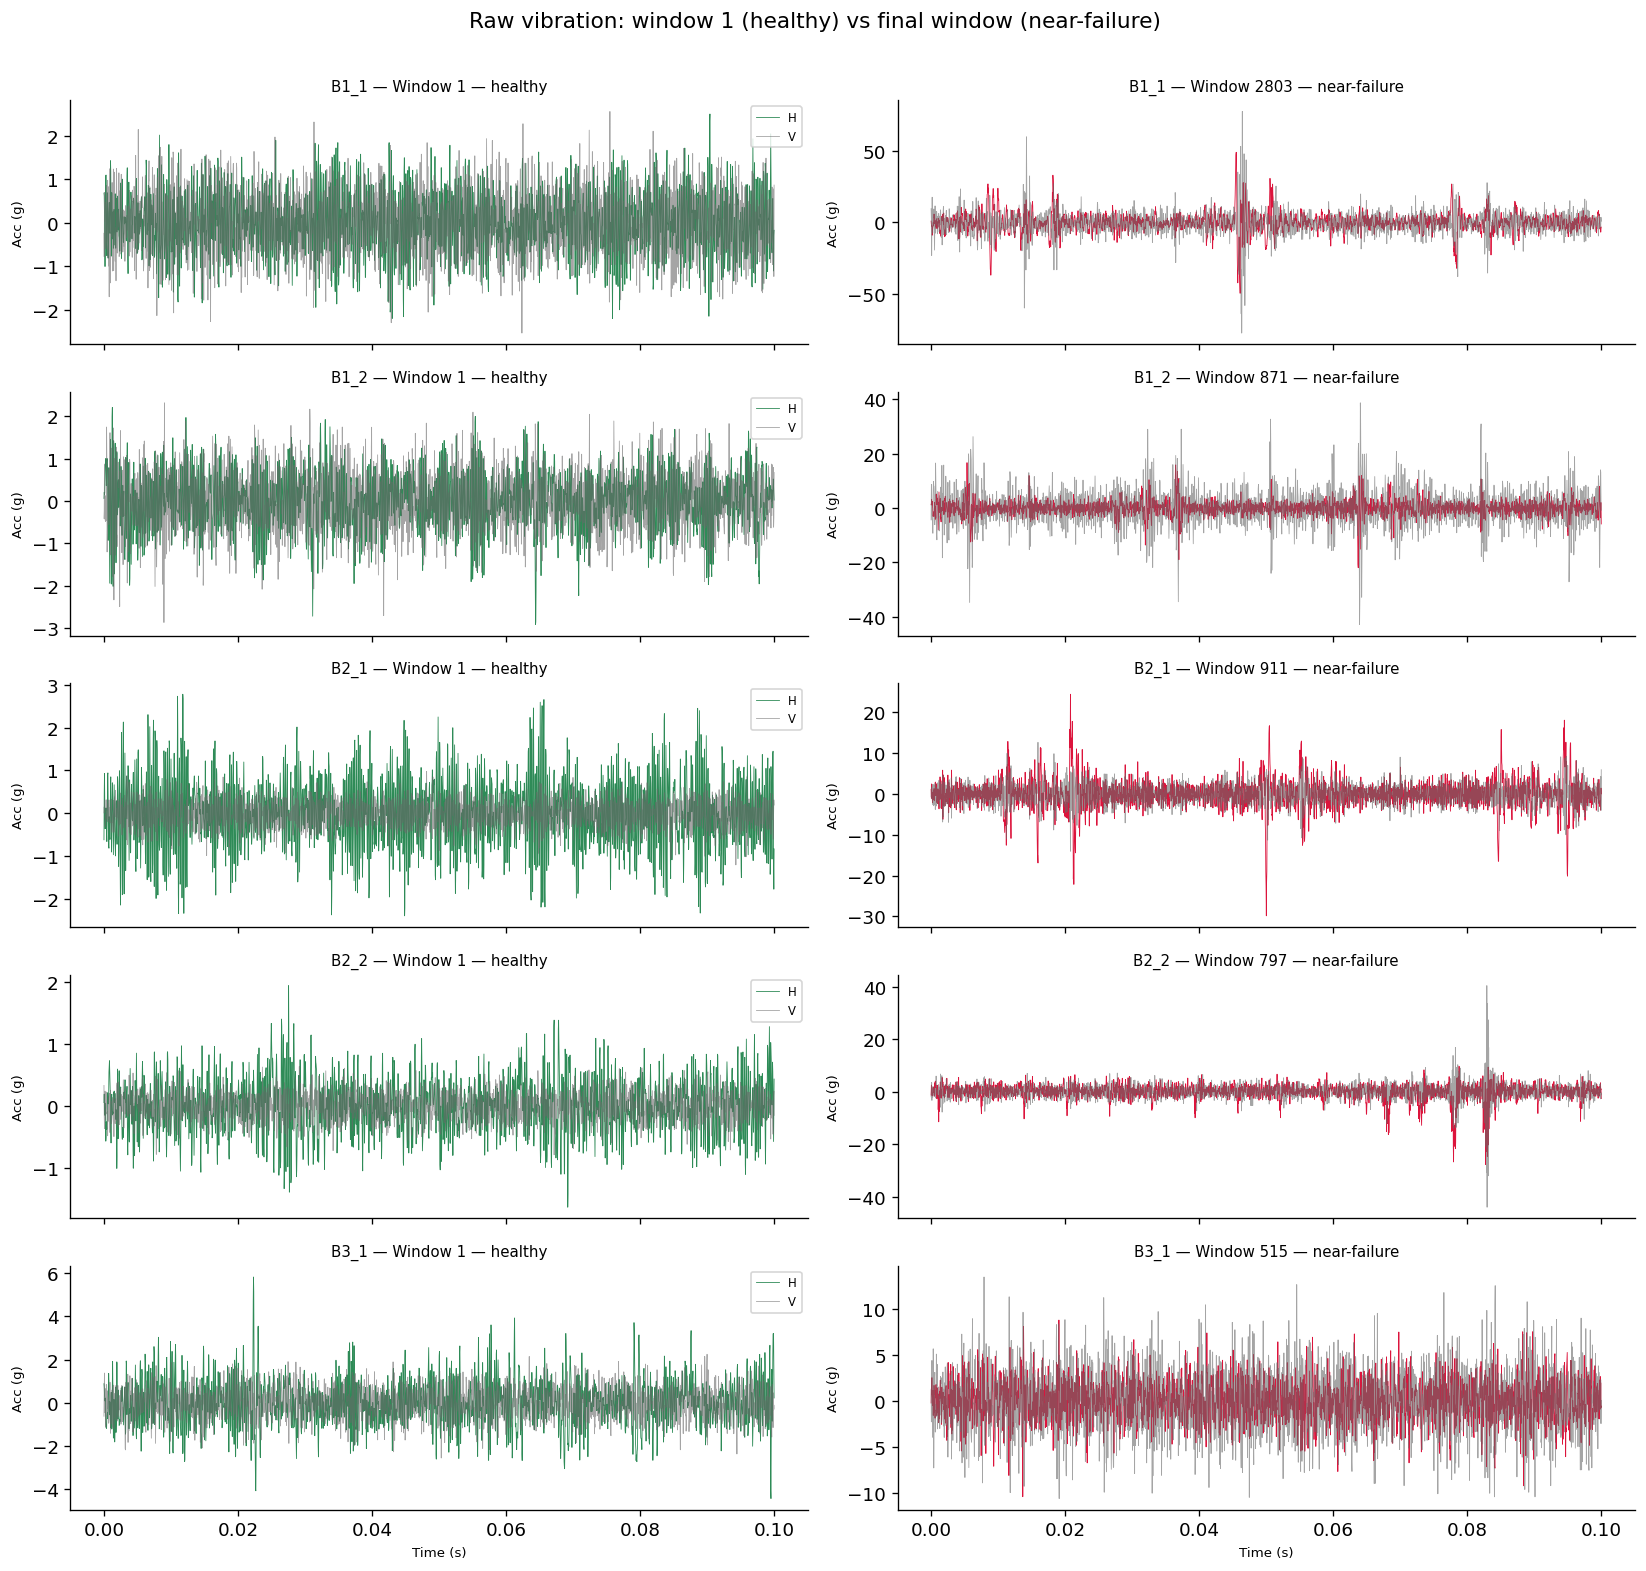

  ✓ Plot saved: eda_raw_signals.png


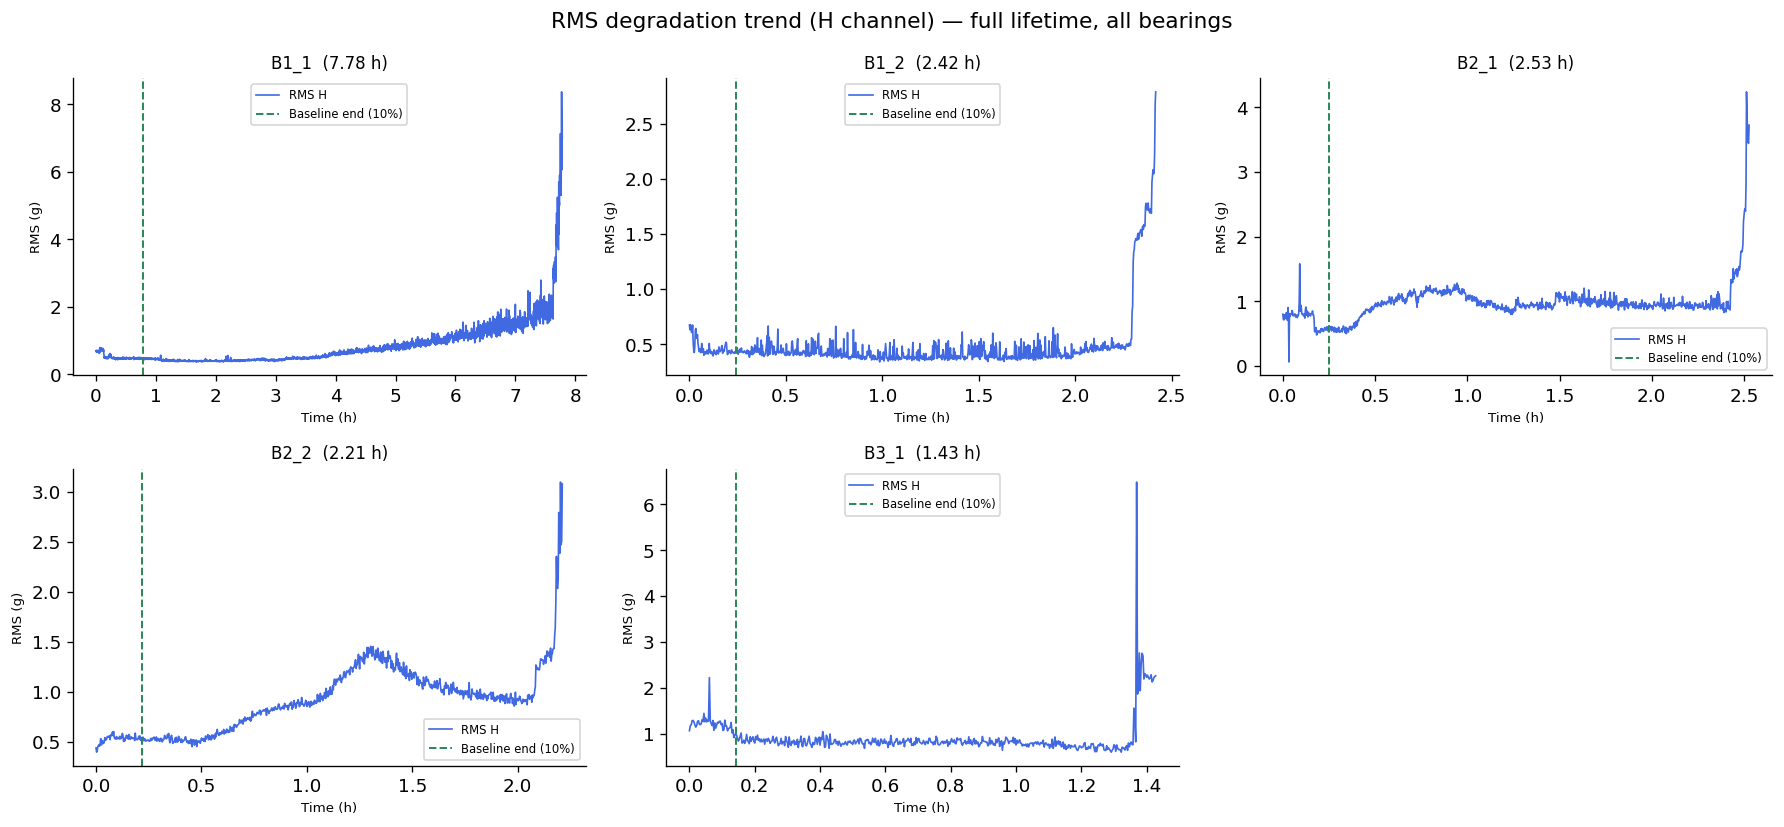

  ✓ Plot saved: eda_rms_trends.png

Data quality checks:
  ✓ B1_1: all 2803 windows finite, shape (2803, 2560, 2)
  ✓ B1_2: all 871 windows finite, shape (871, 2560, 2)
  ✓ B2_1: all 911 windows finite, shape (911, 2560, 2)
  ✓ B2_2: all 797 windows finite, shape (797, 2560, 2)
  ✓ B3_1: all 515 windows finite, shape (515, 2560, 2)

✓ Cell 02 complete — data understanding done.


In [2]:
"""
=============================================================================
CRISP-DM Phase 2: Data Understanding
=============================================================================
What this cell does
-------------------
  1. Loads all training bearings via FemtoReader (fd=1,2,3)
  2. Prints dataset inventory — windows, lifetime, RUL range per bearing
  3. Plots raw vibration signals: first vs last window (healthy vs failing)
  4. Plots RMS degradation trend over lifetime for all bearings
  5. Data quality checks

Data structure (confirmed from reader.load_split output)
---------------------------------------------------------
  features : (n_windows, 2560, 2)
               axis-0 = time steps (one per 10 s interval)
               axis-1 = 2560 samples in the 0.1 s burst
               axis-2 = [acc_h, acc_v]
  targets  : (n_windows,)  RUL in cycles (1 cycle = 10 s)

Operating conditions
--------------------
  fd=1 : 1800 rpm, 4000 N  →  Bearing1_1, Bearing1_2
  fd=2 : 1650 rpm, 4200 N  →  Bearing2_1, Bearing2_2
  fd=3 : 1500 rpm, 5000 N  →  Bearing3_1, Bearing3_2
=============================================================================
"""

from typing import List

# Lambda: convert RUL cycles → hours (1 cycle = 10 s)
cycles_to_hours = lambda cycles: cycles * 10 / 3600

all_features: List[np.ndarray] = []
all_targets:  List[np.ndarray] = []
all_names:    List[str]        = []

print("Loading FEMTO learning set via rul-datasets...\n")

for fd in [1, 2, 3]:
    reader = rul_datasets.reader.FemtoReader(fd=fd)
    reader.prepare_data()
    feats, tgts = reader.load_split("dev")

    for i, (f, t) in enumerate(zip(feats, tgts)):
        arr_f = f.numpy() if hasattr(f, "numpy") else np.array(f)
        arr_t = t.numpy() if hasattr(t, "numpy") else np.array(t)
        name  = f"B{fd}_{i+1}"
        all_features.append(arr_f)
        all_targets.append(arr_t)
        all_names.append(name)

        print(f"  ✓ {name:6s}  fd={fd}  "
              f"{len(arr_t):>5} windows  "
              f"{cycles_to_hours(len(arr_t)):.2f} h lifetime  "
              f"RUL max={arr_t.max():.0f} cycles")

print(f"\n  Total bearings loaded : {len(all_features)}")

# ---------------------------------------------------------------------------
# Dataset inventory table
# ---------------------------------------------------------------------------
inventory_df = pd.DataFrame([
    {
        "Bearing"       : name,
        "Windows"       : len(t),
        "Lifetime (h)"  : round(cycles_to_hours(len(t)), 3),
        "RUL max (cyc)" : int(t.max()),
        "RUL min (cyc)" : int(t.min()),
    }
    for name, t in zip(all_names, all_targets)
])
print("\nDataset inventory:")
print(inventory_df.to_string(index=False))

rul_maxes = [t.max() for t in all_targets]
print(f"\n  ⚠  RUL range across bearings: "
      f"{int(min(rul_maxes))} – {int(max(rul_maxes))} cycles "
      f"({cycles_to_hours(min(rul_maxes)):.2f}h – "
      f"{cycles_to_hours(max(rul_maxes)):.2f}h)")
print("     → This scale mismatch is why raw RUL as model target fails.")
print("     → Fix: normalise RUL to [0,1] per bearing (done in Cell 03).")

# ---------------------------------------------------------------------------
# Plot 1: Raw vibration — first vs last window per bearing
# ---------------------------------------------------------------------------
t_axis = np.linspace(0, 0.1, WINDOW_LEN)

fig, axes = plt.subplots(
    len(all_features), 2,
    figsize=(14, 2.6 * len(all_features)),
    sharex=True,
)
fig.suptitle(
    "Raw vibration: window 1 (healthy) vs final window (near-failure)",
    fontsize=13, y=1.005,
)

for row, (name, feats) in enumerate(zip(all_names, all_features)):
    for col, (window, label, colour) in enumerate([
        (feats[0],  "Window 1 — healthy",                  C_OK),
        (feats[-1], f"Window {len(feats)} — near-failure",  C_DANGER),
    ]):
        ax = axes[row, col]
        ax.plot(t_axis, window[:, 0], color=colour, lw=0.5, label="H")
        ax.plot(t_axis, window[:, 1], color=C_GREY,  lw=0.5, alpha=0.6, label="V")
        ax.set_title(f"{name} — {label}", fontsize=9)
        ax.set_ylabel("Acc (g)", fontsize=8)
        if row == len(all_features) - 1:
            ax.set_xlabel("Time (s)", fontsize=8)
        if col == 0:
            ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("eda_raw_signals.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: eda_raw_signals.png")

# ---------------------------------------------------------------------------
# Plot 2: RMS degradation trend — all bearings
# Lambda: per-window RMS on horizontal channel
# ---------------------------------------------------------------------------
rms_h_of = lambda feats: np.sqrt(np.mean(feats[:, :, 0] ** 2, axis=1))

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle(
    "RMS degradation trend (H channel) — full lifetime, all bearings",
    fontsize=13,
)

for ax, (name, feats) in zip(axes.flat, zip(all_names, all_features)):
    rms_h    = rms_h_of(feats)
    time_h   = np.arange(len(rms_h)) * 10 / 3600
    base_idx = int(len(rms_h) * BASELINE_PCT)

    ax.plot(time_h, rms_h, color=C_PRIMARY, lw=1.0, label="RMS H")
    ax.axvline(
        x=time_h[base_idx],
        color=C_OK, lw=1.2, ls="--",
        label=f"Baseline end ({int(BASELINE_PCT * 100)}%)",
    )
    ax.set_title(f"{name}  ({time_h[-1]:.2f} h)", fontsize=10)
    ax.set_xlabel("Time (h)", fontsize=8)
    ax.set_ylabel("RMS (g)", fontsize=8)
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("eda_rms_trends.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: eda_rms_trends.png")

# ---------------------------------------------------------------------------
# Data quality check
# ---------------------------------------------------------------------------
print("\nData quality checks:")
for name, feats in zip(all_names, all_features):
    bad = np.where(np.any(~np.isfinite(feats), axis=(1, 2)))[0]
    if len(bad):
        print(f"  ✗ {name}: {len(bad)} windows with NaN/Inf — indices {bad[:5]}")
    else:
        print(f"  ✓ {name}: all {len(feats)} windows finite, shape {feats.shape}")

print("\n✓ Cell 02 complete — data understanding done.")

In [3]:
import rul_datasets

reader = rul_datasets.reader.FemtoReader(fd=1)
reader.prepare_data()

train_features, train_targets = reader.load_split("dev")
print(f"Number of bearings in dev split: {len(train_features)}")
print(f"Bearing 0 features shape: {train_features[0].shape}")
print(f"Bearing 0 targets shape:  {train_targets[0].shape}")

Number of bearings in dev split: 2
Bearing 0 features shape: (2803, 2560, 2)
Bearing 0 targets shape:  (2803,)


Extracting features (bandpass + 10 statistical features per window)...
This takes ~30–60 s for 5 bearings × ~1000 windows each.

  ✓ B1_1    feature matrix shape: (2803, 10)
  ✓ B1_2    feature matrix shape: (871, 10)
  ✓ B2_1    feature matrix shape: (911, 10)
  ✓ B2_2    feature matrix shape: (797, 10)
  ✓ B3_1    feature matrix shape: (515, 10)

  Feature names: ['rms_h', 'rms_v', 'kurt_h', 'kurt_v', 'crest_h', 'crest_v', 'skew_h', 'skew_v', 'impulse_h', 'impulse_v']

Constructing Health Indicators (HI)...
  ✓ B1_1    HI range: [0.000, 1.000]  mean=0.010
  ✓ B1_2    HI range: [0.000, 1.000]  mean=0.021
  ✓ B2_1    HI range: [0.000, 1.000]  mean=0.011
  ✓ B2_2    HI range: [0.000, 1.000]  mean=0.024
  ✓ B3_1    HI range: [0.000, 1.000]  mean=0.012


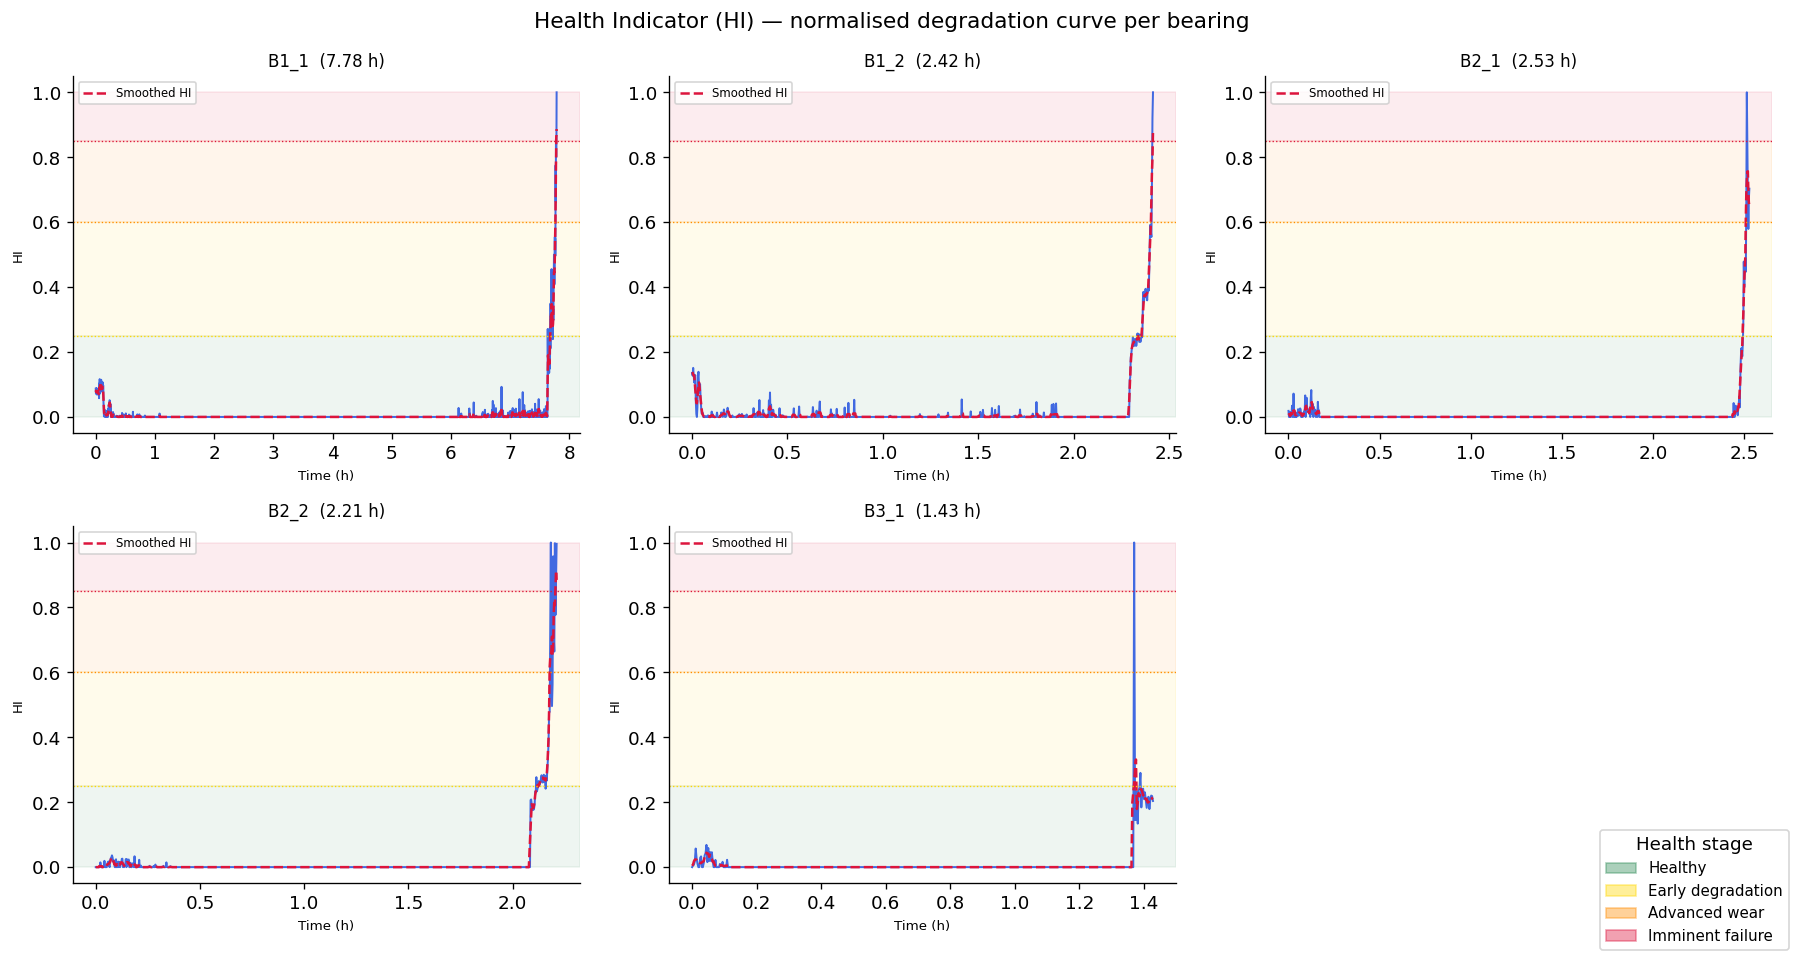

  ✓ Plot saved: hi_curves.png

  X shape  : (5897, 10)  (windows × features)
  groups   : (5897,)  (bearing IDs for LOBO)

✓ Cell 03 complete — features and HI ready.
  Note: class labels and y_rul built in Cell 03c from normalised RUL.


In [4]:
"""
=============================================================================
CRISP-DM Phase 3: Data Preparation — Feature Engineering + HI Construction
=============================================================================
What this cell does
-------------------
  1. Bandpass filter each window (2–10 kHz) — isolates bearing fault freqs
  2. Extract 5 statistical features per channel (H + V) = 10 features total
  3. Build Health Indicator (HI) per bearing — normalised RUL proxy [0→1]
  4. Plot HI curves for all 5 bearings — visual sanity check
  5. Build final feature matrix X

Why bandpass 2–10 kHz?
-----------------------
  Bearing fault frequencies (BPFO, BPFI, BSF) on FEMTO at 1500–1800 rpm
  fall in this band. Below 2 kHz = shaft/structural noise. Above 10 kHz =
  high-freq noise unrelated to bearing defects. Standard in literature
  (Sutrisno 2012, Cheng 2018).

Features and physical meaning
------------------------------
  RMS           : overall energy — primary degradation indicator, rises with wear
  Kurtosis      : signal spikiness — sensitive to early impulsive faults
  Crest factor  : peak / RMS — moves OPPOSITE to RMS as fault progresses
  Skewness      : signal asymmetry — zero for healthy, shifts with fault onset
  Impulse factor: peak / mean(|x|) — sensitive to single sharp spikes

Health Indicator (HI) construction
------------------------------------
  HI = (RMS_current - RMS_baseline) / (RMS_max - RMS_baseline)
  Baseline = median RMS of first 10% of bearing life (healthy state)
  Maps every bearing to [0.0 → 1.0] regardless of absolute vibration level.
  This fixes the cross-bearing scale mismatch identified in Cell 02.
  Note: HI is used for visualisation only — class labels derived from
  normalised RUL in Cell 03c (more consistent across conditions).
=============================================================================
"""

from typing import List
from scipy.signal import butter, filtfilt

# ---------------------------------------------------------------------------
# Bandpass filter — built once, reused via lambda
# ---------------------------------------------------------------------------
def _make_bp_filter(
    lowcut: float, highcut: float, fs: float, order: int
) -> tuple:
    """Return (b, a) Butterworth bandpass coefficients."""
    nyq  = fs / 2.0
    low  = lowcut  / nyq
    high = highcut / nyq
    return butter(order, [low, high], btype="band")


_BP_B, _BP_A = _make_bp_filter(BP_LOW, BP_HIGH, FS, BP_ORDER)

# Lambda: apply zero-phase bandpass to a 1-D signal array
apply_bandpass = lambda x: filtfilt(_BP_B, _BP_A, x)

# ---------------------------------------------------------------------------
# Feature lambdas — all operate on a 1-D filtered signal array
# ---------------------------------------------------------------------------
feat_rms     = lambda x: np.sqrt(np.mean(x ** 2))
feat_kurt    = lambda x: kurtosis(x, fisher=True)
feat_crest   = lambda x: np.max(np.abs(x)) / (feat_rms(x) + 1e-10)
feat_skew    = lambda x: skew(x)
feat_impulse = lambda x: np.max(np.abs(x)) / (np.mean(np.abs(x)) + 1e-10)

FEATURE_NAMES = [
    "rms_h",     "rms_v",
    "kurt_h",    "kurt_v",
    "crest_h",   "crest_v",
    "skew_h",    "skew_v",
    "impulse_h", "impulse_v",
]


# ---------------------------------------------------------------------------
# Core: extract features from one (2560, 2) window
# ---------------------------------------------------------------------------
def extract_features(window: np.ndarray) -> np.ndarray:
    """
    Apply bandpass filter then compute 5 features × 2 channels.
    Returns 1-D array of length 10.
    """
    sig_h = apply_bandpass(window[:, 0].astype(np.float64))
    sig_v = apply_bandpass(window[:, 1].astype(np.float64))
    return np.array([
        feat_rms(sig_h),     feat_rms(sig_v),
        feat_kurt(sig_h),    feat_kurt(sig_v),
        feat_crest(sig_h),   feat_crest(sig_v),
        feat_skew(sig_h),    feat_skew(sig_v),
        feat_impulse(sig_h), feat_impulse(sig_v),
    ], dtype=np.float32)


# ---------------------------------------------------------------------------
# Extract features for all bearings
# ---------------------------------------------------------------------------
print("Extracting features (bandpass + 10 statistical features per window)...")
print("This takes ~30–60 s for 5 bearings × ~1000 windows each.\n")

bearing_features: List[np.ndarray] = []

for name, feats in zip(all_names, all_features):
    feat_matrix = np.vstack([extract_features(w) for w in feats])
    bearing_features.append(feat_matrix)
    print(f"  ✓ {name:6s}  feature matrix shape: {feat_matrix.shape}")

print(f"\n  Feature names: {FEATURE_NAMES}")

# ---------------------------------------------------------------------------
# Health Indicator (HI) construction — visualisation only
# ---------------------------------------------------------------------------
print("\nConstructing Health Indicators (HI)...")


def compute_hi(feat_matrix: np.ndarray) -> np.ndarray:
    """
    Normalise RMS-H to [0, 1] using healthy baseline (first BASELINE_PCT).
    HI=0 → healthy, HI=1 → failure.
    """
    rms_h    = feat_matrix[:, 0]
    base_end = max(1, int(len(rms_h) * BASELINE_PCT))
    baseline = np.median(rms_h[:base_end])
    denom    = rms_h.max() - baseline
    if denom < 1e-10:
        return np.zeros(len(rms_h), dtype=np.float32)
    hi = (rms_h - baseline) / denom
    return np.clip(hi, 0.0, 1.0).astype(np.float32)


bearing_hi: List[np.ndarray] = [compute_hi(fm) for fm in bearing_features]

for name, hi in zip(all_names, bearing_hi):
    print(f"  ✓ {name:6s}  HI range: [{hi.min():.3f}, {hi.max():.3f}]  "
          f"mean={hi.mean():.3f}")

# ---------------------------------------------------------------------------
# Plot: HI curves for all bearings
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    "Health Indicator (HI) — normalised degradation curve per bearing",
    fontsize=13,
)

for ax, (name, hi) in zip(axes.flat, zip(all_names, bearing_hi)):
    time_h = np.arange(len(hi)) * 10 / 3600

    for (lo, hi_band), colour in zip(
        zip(HI_THRESHOLDS[:-1], HI_THRESHOLDS[1:]), HEALTH_COLOURS
    ):
        ax.axhspan(lo, min(hi_band, 1.0), alpha=0.08, color=colour)

    ax.plot(time_h, hi, color=C_PRIMARY, lw=1.2)

    smooth_hi = (
        pd.Series(hi)
        .rolling(HI_SMOOTH_WIN, center=True, min_periods=1)
        .mean()
        .values
    )
    ax.plot(time_h, smooth_hi, color=C_DANGER, lw=1.5,
            ls="--", label="Smoothed HI")

    for thresh, colour in zip(HI_THRESHOLDS[1:-1], HEALTH_COLOURS[1:]):
        ax.axhline(thresh, color=colour, lw=0.8, ls=":")

    ax.set_title(f"{name}  ({time_h[-1]:.2f} h)", fontsize=10)
    ax.set_xlabel("Time (h)", fontsize=8)
    ax.set_ylabel("HI", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)

patches = [
    mpatches.Patch(color=c, alpha=0.4, label=l)
    for c, l in zip(HEALTH_COLOURS, HEALTH_LABELS)
]
fig.legend(handles=patches, loc="lower right", fontsize=9, title="Health stage")
plt.tight_layout()
plt.savefig("hi_curves.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: hi_curves.png")

# ---------------------------------------------------------------------------
# Build feature matrix X
# ---------------------------------------------------------------------------
X      = np.vstack(bearing_features)   # (N_total, 10)
groups = np.concatenate([
    np.full(len(f), i) for i, f in enumerate(bearing_features)
])

print(f"\n  X shape  : {X.shape}  (windows × features)")
print(f"  groups   : {groups.shape}  (bearing IDs for LOBO)")
print("\n✓ Cell 03 complete — features and HI ready.")
print("  Note: class labels and y_rul built in Cell 03c from normalised RUL.")

Recomputing HI via RMS + Kurtosis PCA fusion...

  ✓ B1_1    HI range: [0.001, 0.949]  mean=0.058  PC1 explained variance: 80.8%
  ✓ B1_2    HI range: [0.017, 0.976]  mean=0.308  PC1 explained variance: 61.3%
  ✓ B2_1    HI range: [0.037, 0.991]  mean=0.497  PC1 explained variance: 55.5%
  ✓ B2_2    HI range: [0.001, 0.934]  mean=0.066  PC1 explained variance: 90.3%
  ✓ B3_1    HI range: [0.001, 0.943]  mean=0.093  PC1 explained variance: 65.7%


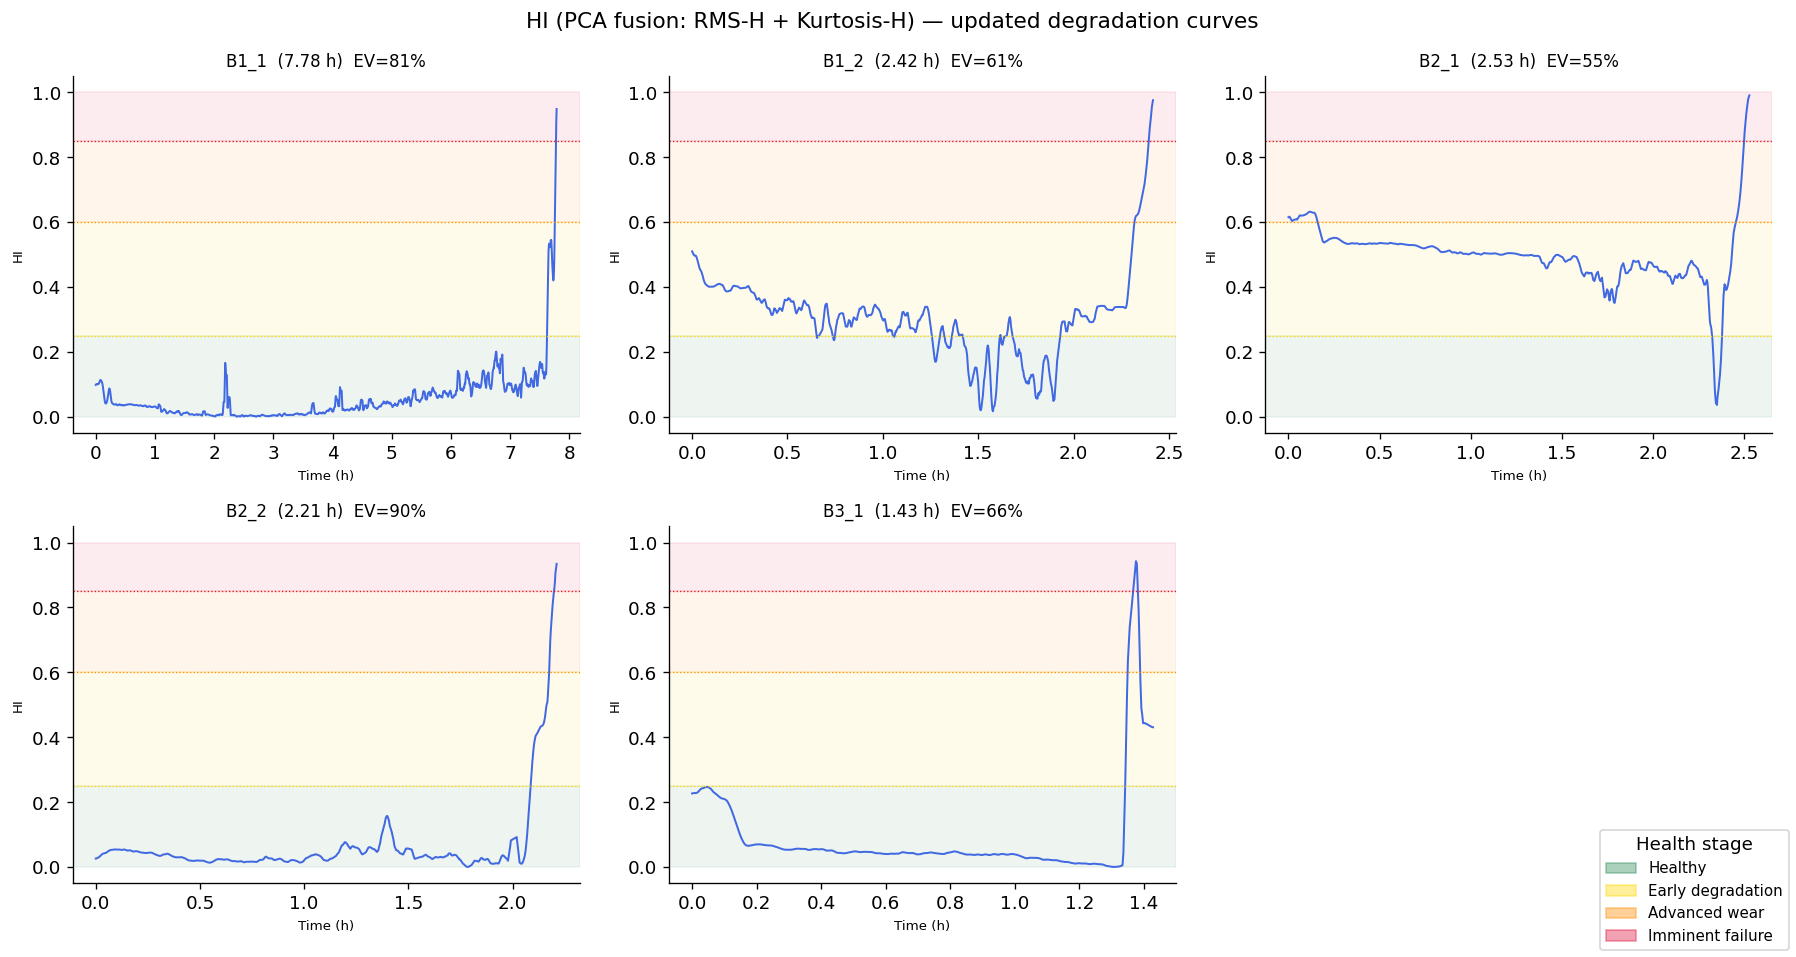

  ✓ Plot saved: hi_curves_pca.png

✓ Cell 03b complete — PCA HI ready. Class labels built in Cell 03c.


In [5]:
"""
=============================================================================
Cell 03b — HI Fix: RMS + Kurtosis fusion via PCA
=============================================================================
Problem identified in Cell 03
------------------------------
  RMS-only HI was flat at ~0 for 98% of bearing life, spiking only at
  end-of-life. Class distribution: 98% Healthy, 2% everything else.
  A model predicting "Healthy" always would score 98% accuracy — useless.

Fix
---
  Fuse RMS-H and Kurtosis-H via PCA. PC1 captures the shared degradation
  trend across both features. Kurtosis detects early impulsive faults that
  RMS misses — fusing them gives a more gradual, informative HI curve.

  Steps per bearing:
    1. Extract smoothed RMS-H and Kurtosis-H time series
    2. Stack as (n_windows, 2) matrix
    3. Fit PCA(n_components=1) → PC1 is the fused degradation score
    4. Normalise PC1 to [0, 1] → HI
    5. Apply rolling smoothing to reduce noise

  Note: HI used for visualisation only.
  Class labels derived from normalised RUL in Cell 03c.
=============================================================================
"""

from typing import List, Tuple

TREND_SMOOTH_WIN = 15   # windows (~2.5 min) — smoothing before PCA


def compute_hi_pca(feat_matrix: np.ndarray) -> Tuple[np.ndarray, float]:
    """
    Fuse RMS-H (col 0) and Kurtosis-H (col 2) via PCA.
    Returns (HI array normalised to [0, 1], explained variance ratio).
    """
    rms_h  = feat_matrix[:, 0].astype(np.float64)
    kurt_h = feat_matrix[:, 2].astype(np.float64)

    # Lambda: rolling mean smoothing on a 1-D array
    smooth = lambda arr: (
        pd.Series(arr)
        .rolling(TREND_SMOOTH_WIN, center=True, min_periods=1)
        .mean()
        .values
    )

    Z     = np.column_stack([smooth(rms_h), smooth(kurt_h)])
    Z_std = (Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-10)
    pca   = PCA(n_components=1)
    pc1   = pca.fit_transform(Z_std).ravel()
    ev    = pca.explained_variance_ratio_[0]

    pc1_norm = (pc1 - pc1.min()) / (pc1.max() - pc1.min() + 1e-10)

    # Flip if PC1 trends downward — PCA sign is arbitrary
    if pc1_norm[0] > pc1_norm[-1]:
        pc1_norm = 1.0 - pc1_norm

    hi_smooth = (
        pd.Series(pc1_norm)
        .rolling(HI_SMOOTH_WIN, center=True, min_periods=1)
        .mean()
        .values
    )
    return np.clip(hi_smooth, 0.0, 1.0).astype(np.float32), ev


# ---------------------------------------------------------------------------
# Recompute HI for all bearings using PCA fusion
# ---------------------------------------------------------------------------
print("Recomputing HI via RMS + Kurtosis PCA fusion...\n")

bearing_hi:    List[np.ndarray] = []
explained_vars: List[float]     = []

for name, fm in zip(all_names, bearing_features):
    hi, ev = compute_hi_pca(fm)
    bearing_hi.append(hi)
    explained_vars.append(ev)
    print(f"  ✓ {name:6s}  HI range: [{hi.min():.3f}, {hi.max():.3f}]  "
          f"mean={hi.mean():.3f}  PC1 explained variance: {ev:.1%}")

# ---------------------------------------------------------------------------
# Plot: updated HI curves
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    "HI (PCA fusion: RMS-H + Kurtosis-H) — updated degradation curves",
    fontsize=13,
)

for ax, (name, hi, ev) in zip(
    axes.flat, zip(all_names, bearing_hi, explained_vars)
):
    time_h = np.arange(len(hi)) * 10 / 3600

    for (lo, hi_band), colour in zip(
        zip(HI_THRESHOLDS[:-1], HI_THRESHOLDS[1:]), HEALTH_COLOURS
    ):
        ax.axhspan(lo, min(hi_band, 1.0), alpha=0.08, color=colour)

    ax.plot(time_h, hi, color=C_PRIMARY, lw=1.2)

    for thresh, colour in zip(HI_THRESHOLDS[1:-1], HEALTH_COLOURS[1:]):
        ax.axhline(thresh, color=colour, lw=0.8, ls=":")

    ax.set_title(f"{name}  ({time_h[-1]:.2f} h)  EV={ev:.0%}", fontsize=10)
    ax.set_xlabel("Time (h)", fontsize=8)
    ax.set_ylabel("HI", fontsize=8)
    ax.set_ylim(-0.05, 1.05)

axes.flat[-1].set_visible(False)

patches = [
    mpatches.Patch(color=c, alpha=0.4, label=l)
    for c, l in zip(HEALTH_COLOURS, HEALTH_LABELS)
]
fig.legend(handles=patches, loc="lower right", fontsize=9, title="Health stage")
plt.tight_layout()
plt.savefig("hi_curves_pca.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: hi_curves_pca.png")
print("\n✓ Cell 03b complete — PCA HI ready. Class labels built in Cell 03c.")

Computing class labels from normalised RUL...

Class distribution per bearing (RUL-based):
  B1_1    Healthy=701 (25%)  Early de=981 (35%)  Advanced=701 (25%)  Imminent=420 (15%)
  B1_2    Healthy=218 (25%)  Early de=305 (35%)  Advanced=218 (25%)  Imminent=130 (15%)
  B2_1    Healthy=228 (25%)  Early de=319 (35%)  Advanced=228 (25%)  Imminent=136 (15%)
  B2_2    Healthy=200 (25%)  Early de=279 (35%)  Advanced=199 (25%)  Imminent=119 (15%)
  B3_1    Healthy=129 (25%)  Early de=181 (35%)  Advanced=128 (25%)  Imminent=77 (15%)

Final dataset shapes:
  X       : (5897, 10)
  y_rul   : (5897,)  range [0.000, 1.000]
  y_class : (5897,)

Overall class distribution:
  0 Healthy             :  1476 (25.0%)  ██████████
  1 Early degradation   :  2065 (35.0%)  ██████████████
  2 Advanced wear       :  1474 (25.0%)  █████████
  3 Imminent failure    :   882 (15.0%)  █████


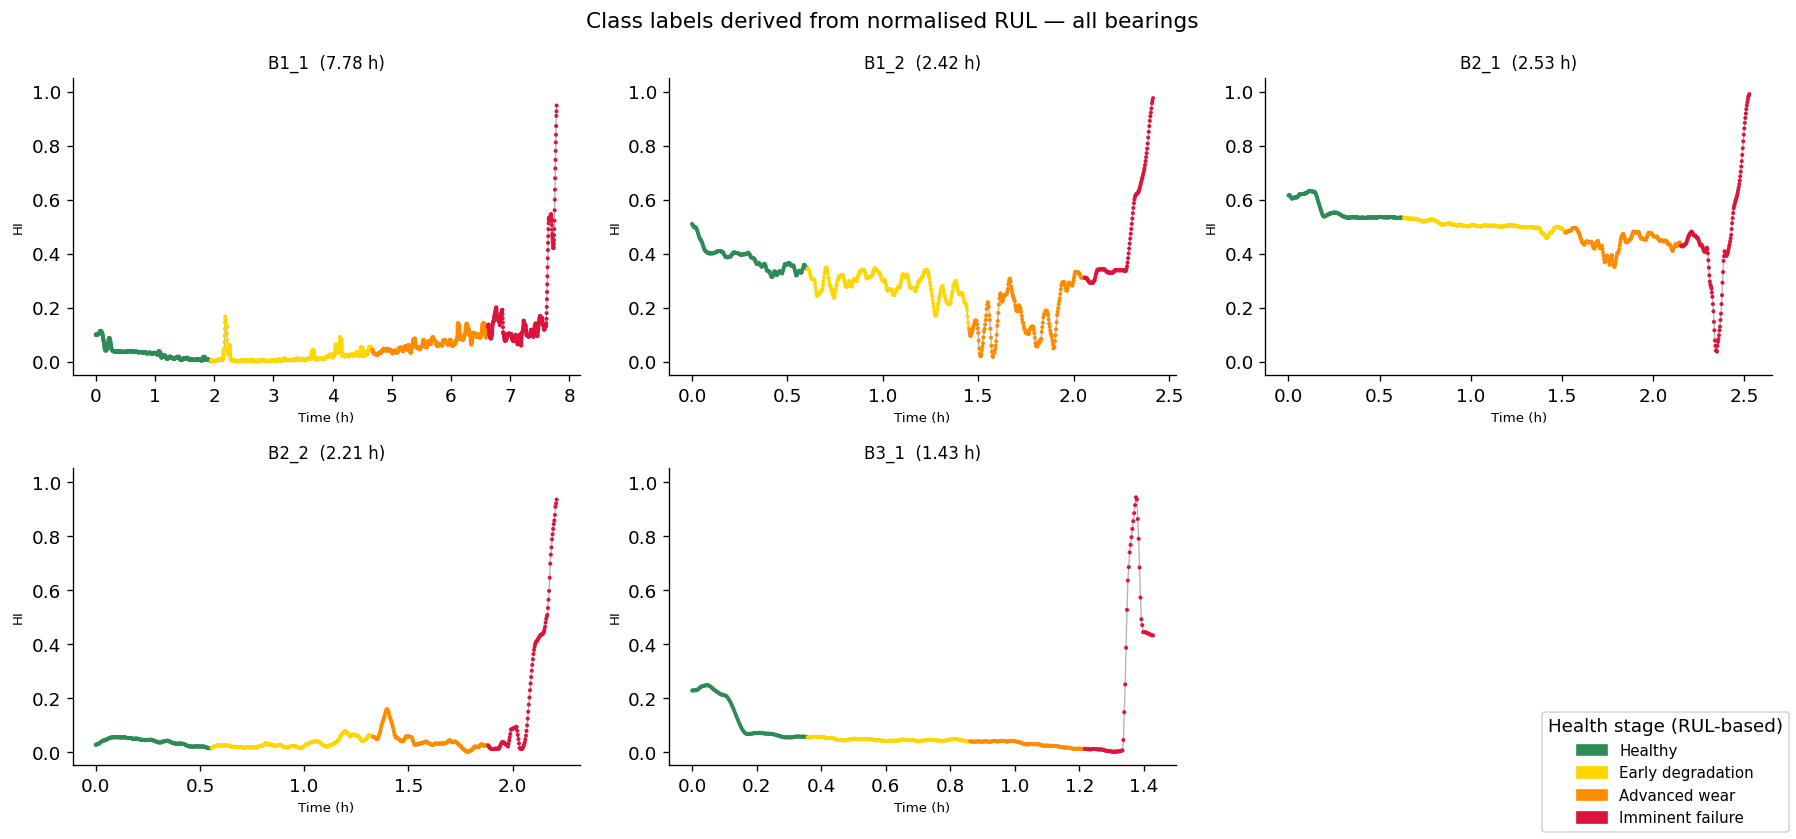


  ✓ Plot saved: class_labels_rul.png

✓ Cell 03c complete — RUL-based class labels ready.


In [6]:
"""
=============================================================================
Cell 03c — Class Labels: derive 4 health stages from normalised RUL
=============================================================================
Problem with HI-based classes (Cell 03b)
-----------------------------------------
  PCA HI is condition-dependent — different RPM/load conditions produce
  different absolute vibration levels, so PCA learns a different degradation
  direction per bearing. B2_1 started at HI=0.6 (appeared already degraded
  at t=0), which is physically wrong. Class distributions were inconsistent:
  B1_1=98% Healthy vs B2_1=2% Healthy.

Fix: classes from normalised RUL
----------------------------------
  Prof definition: RUL = lifetime − current usage
  Normalised RUL (y_rul) = RUL / max_RUL → [0, 1] per bearing
  0.0 = failure,  1.0 = brand new

  Class thresholds on normalised RUL:
    Healthy          : RUL_norm in [0.75, 1.0]   >75% life remaining
    Early degradation: RUL_norm in [0.40, 0.75]  40–75% remaining
    Advanced wear    : RUL_norm in [0.15, 0.40]  15–40% remaining
    Imminent failure : RUL_norm in [0.00, 0.15]  <15% remaining

  Guarantees consistent 25/35/25/15 split across all bearings regardless
  of operating condition or absolute vibration level.
  HI (PCA) kept for visualisation only — not used for labels.
=============================================================================
"""

from typing import List

# Lambda: normalise RUL array to [0, 1] per bearing
normalise_rul = lambda rul_arr: rul_arr / rul_arr.max()


def rul_norm_to_class(rul_norm_arr: np.ndarray) -> np.ndarray:
    """Map normalised RUL array → class indices (0=Healthy, 3=Imminent)."""
    classes = np.zeros(len(rul_norm_arr), dtype=np.int64)
    classes[rul_norm_arr < 0.75] = 1   # Early degradation
    classes[rul_norm_arr < 0.40] = 2   # Advanced wear
    classes[rul_norm_arr < 0.15] = 3   # Imminent failure
    return classes


# ---------------------------------------------------------------------------
# Compute class labels from normalised RUL
# ---------------------------------------------------------------------------
print("Computing class labels from normalised RUL...\n")

bearing_rul_norm: List[np.ndarray] = [normalise_rul(t) for t in all_targets]
bearing_classes:  List[np.ndarray] = [rul_norm_to_class(r) for r in bearing_rul_norm]

print("Class distribution per bearing (RUL-based):")
for name, classes in zip(all_names, bearing_classes):
    counts = np.bincount(classes, minlength=4)
    total  = len(classes)
    dist   = "  ".join(
        f"{HEALTH_LABELS[i][:8]}={counts[i]} ({counts[i] / total:.0%})"
        for i in range(4)
    )
    print(f"  {name:6s}  {dist}")

# ---------------------------------------------------------------------------
# Final targets
# ---------------------------------------------------------------------------
y_rul   = np.concatenate(bearing_rul_norm).astype(np.float32)
y_class = np.concatenate(bearing_classes)

print(f"\nFinal dataset shapes:")
print(f"  X       : {X.shape}")
print(f"  y_rul   : {y_rul.shape}  range [{y_rul.min():.3f}, {y_rul.max():.3f}]")
print(f"  y_class : {y_class.shape}")

counts_total = np.bincount(y_class)
total        = len(y_class)
print(f"\nOverall class distribution:")
for i, (label, count) in enumerate(zip(HEALTH_LABELS, counts_total)):
    bar = "█" * int(count / total * 40)
    print(f"  {i} {label:20s}: {count:5d} ({count / total:.1%})  {bar}")

# ---------------------------------------------------------------------------
# Plot: RUL-based class labels overlaid on HI curve
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle(
    "Class labels derived from normalised RUL — all bearings",
    fontsize=13,
)

for ax, (name, classes, hi) in zip(
    axes.flat, zip(all_names, bearing_classes, bearing_hi)
):
    time_h  = np.arange(len(classes)) * 10 / 3600
    colours = [HEALTH_COLOURS[c] for c in classes]

    ax.plot(time_h, hi, color=C_GREY, lw=0.8, alpha=0.5, label="HI (ref)")
    ax.scatter(time_h, hi, c=colours, s=2, zorder=3)

    ax.set_title(f"{name}  ({time_h[-1]:.2f} h)", fontsize=10)
    ax.set_xlabel("Time (h)", fontsize=8)
    ax.set_ylabel("HI", fontsize=8)
    ax.set_ylim(-0.05, 1.05)

axes.flat[-1].set_visible(False)

patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(HEALTH_COLOURS, HEALTH_LABELS)
]
fig.legend(handles=patches, loc="lower right",
           fontsize=9, title="Health stage (RUL-based)")

plt.tight_layout()
plt.savefig("class_labels_rul.png", bbox_inches="tight")
plt.show()
print("\n  ✓ Plot saved: class_labels_rul.png")
print("\n✓ Cell 03c complete — RUL-based class labels ready.")

Device: cpu

LOBO CROSS-VALIDATION — CNN + SVR (baseline)

Fold 1/5 — test bearing: B1_1
  Training CNN...
    ep  20  loss=0.00540
    ep  40  loss=0.00424
    ep  60  loss=0.00285
    ep  80  loss=0.00231
    ep 100  loss=0.00349
  Extracting embeddings...
  Training SVR...
  → R²=-0.4746  MAE=2.015 h

Fold 2/5 — test bearing: B1_2
  Training CNN...
    ep  20  loss=0.00335
    ep  40  loss=0.00228
    ep  60  loss=0.00193
    ep  80  loss=0.00156
    ep 100  loss=0.00127
  Extracting embeddings...
  Training SVR...
  → R²=0.5287  MAE=0.398 h

Fold 3/5 — test bearing: B2_1
  Training CNN...
    ep  20  loss=0.00304
    ep  40  loss=0.00225
    ep  60  loss=0.00166
    ep  80  loss=0.00141
    ep 100  loss=0.00125
  Extracting embeddings...
  Training SVR...
  → R²=0.4747  MAE=0.412 h

Fold 4/5 — test bearing: B2_2
  Training CNN...
    ep  20  loss=0.00485
    ep  40  loss=0.00313
    ep  60  loss=0.00218
    ep  80  loss=0.00181
    ep 100  loss=0.00160
  Extracting embeddings...
  

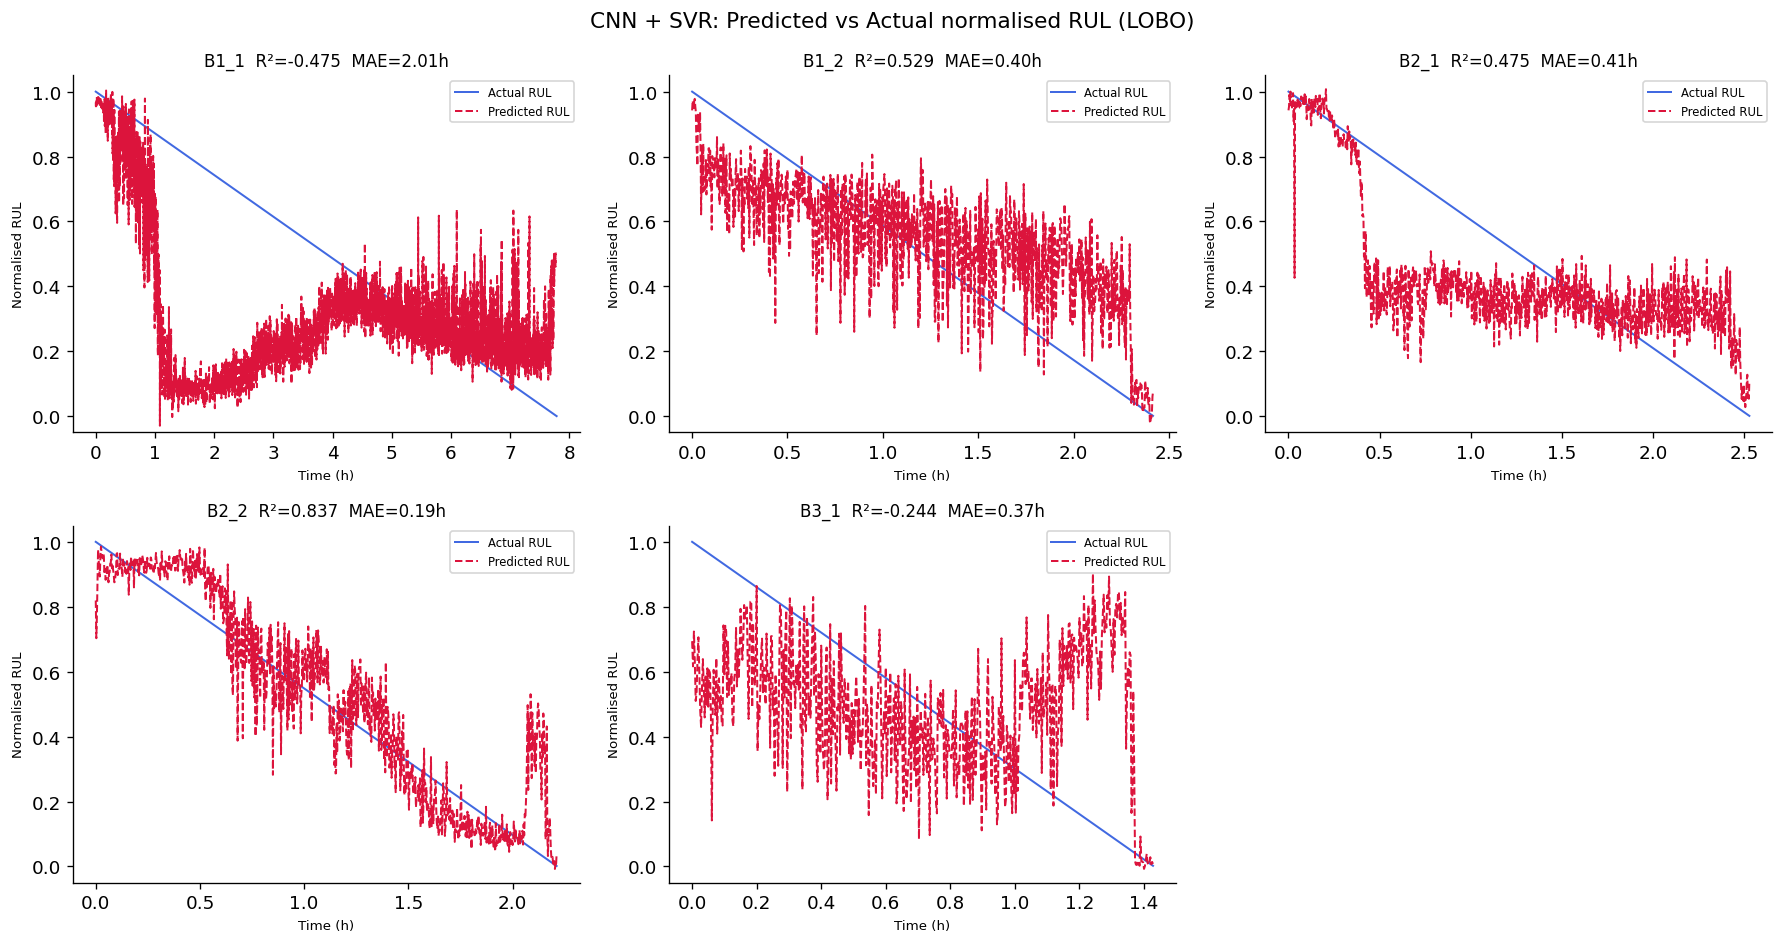

  ✓ Plot saved: cnn_svr_lobo.png

✓ Cell 04 complete — CNN + SVR baseline LOBO results ready.


In [7]:
"""
=============================================================================
CRISP-DM Phase 4: Modelling — CNN Feature Extractor + SVR Regression
=============================================================================
What this cell does
-------------------
  1. Defines a 1D CNN that learns fault patterns from raw vibration windows
  2. Trains CNN on all 5 bearings to predict normalised RUL
  3. Extracts CNN embeddings (learned features) for every window
  4. Trains SVR on CNN embeddings to predict normalised RUL
  5. Evaluates using LOBO (Leave-One-Bearing-Out) cross-validation
  6. Reports R², MAE per bearing and mean across all folds

Why CNN + SVR?
--------------
  Cheng et al. 2018 (the paper prof cited) validated exactly this pipeline
  on FEMTO. CNN extracts local fault patterns (repetitive impulses) from the
  raw 2560-sample window — patterns that hand-crafted features may miss.
  SVR then maps the learned representation to RUL. Small-data friendly:
  SVR works well with only 5 training bearings, unlike LSTM which needs
  many long sequences of consistent length.

Why LOBO validation?
--------------------
  Standard for FEMTO in published literature. Train on 4 bearings,
  test on the held-out 1. Repeats 5 times. Measures true generalisation
  to an unseen bearing — the real-world deployment scenario.

CNN architecture
----------------
  Input  : (batch, 1, 2560)  — single H channel per window
  Conv1  : 16 filters, kernel=64, stride=2  → coarse fault patterns
  Conv2  : 32 filters, kernel=32, stride=2  → finer patterns
  Conv3  : 64 filters, kernel=16, stride=2  → subtle signatures
  GAP    : global average pooling → (batch, 64)  fixed-size embedding
  Head   : Linear(64→1) + Sigmoid → predicts normalised RUL during training
=============================================================================
"""

from typing import List, Tuple

# ---------------------------------------------------------------------------
# CNN architecture
# ---------------------------------------------------------------------------
class BearingCNN(nn.Module):
    """
    1D CNN for bearing degradation feature extraction.
    Trained to predict normalised RUL from a single vibration window.
    After training, the GAP layer output (64-dim) is used as embedding.
    """

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1 — coarse fault patterns
            nn.Conv1d(1, 16, kernel_size=64, stride=2, padding=32),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Block 2 — medium patterns
            nn.Conv1d(16, 32, kernel_size=32, stride=2, padding=16),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Block 3 — fine patterns
            nn.Conv1d(32, 64, kernel_size=16, stride=2, padding=8),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)   # collapses time dim → 64-d vector
        self.head = nn.Sequential(
            nn.Linear(64, 1),
            nn.Sigmoid(),                      # output in [0, 1] = normalised RUL
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Full forward pass — returns predicted RUL (scalar per window)."""
        return self.head(self.gap(self.encoder(x)).squeeze(-1))

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return 64-dim GAP embedding (no head) — used as SVR input."""
        return self.gap(self.encoder(x)).squeeze(-1)


# ---------------------------------------------------------------------------
# Constants + device
# ---------------------------------------------------------------------------
CNN_EPOCHS = 100
CNN_LR     = 1e-3
CNN_BATCH  = 64
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}\n")


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def make_tensors(
    feats_list:  List[np.ndarray],
    rul_list:    List[np.ndarray],
    exclude_idx: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Build train tensors from all bearings except exclude_idx.
    Uses raw H-channel windows: (n_windows, 2560) → (n_windows, 1, 2560).
    """
    X_wins, y_ruls = [], []
    for i, (feats, rul_n) in enumerate(zip(feats_list, rul_list)):
        if i == exclude_idx:
            continue
        wins = feats[:, :, 0].astype(np.float32)[:, np.newaxis, :]
        X_wins.append(wins)
        y_ruls.append(rul_n.astype(np.float32))
    X = torch.tensor(np.vstack(X_wins))
    y = torch.tensor(np.concatenate(y_ruls)).unsqueeze(1)
    return X, y


def train_cnn(
    X_train: torch.Tensor,
    y_train: torch.Tensor,
) -> BearingCNN:
    """Train CNN to predict normalised RUL. Returns trained model."""
    model     = BearingCNN().to(DEVICE)
    optimiser = optim.Adam(model.parameters(), lr=CNN_LR)
    criterion = nn.MSELoss()
    loader    = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=CNN_BATCH, shuffle=True,
    )
    model.train()
    for epoch in range(1, CNN_EPOCHS + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(X_train)
        if epoch % 20 == 0:
            print(f"    ep {epoch:3d}  loss={epoch_loss:.5f}")
    return model


def get_embeddings(model: BearingCNN, feats: np.ndarray) -> np.ndarray:
    """Extract 64-dim CNN embeddings for all windows. Returns (n_windows, 64)."""
    model.eval()
    wins = feats[:, :, 0].astype(np.float32)[:, np.newaxis, :]
    with torch.no_grad():
        emb = model.embed(torch.tensor(wins).to(DEVICE)).cpu().numpy()
    return emb


# ---------------------------------------------------------------------------
# LOBO cross-validation
# ---------------------------------------------------------------------------
print("=" * 60)
print("LOBO CROSS-VALIDATION — CNN + SVR (baseline)")
print("=" * 60)

lobo_results = []

for test_idx, test_name in enumerate(all_names):
    print(f"\nFold {test_idx + 1}/5 — test bearing: {test_name}")
    print("  Training CNN...")
    X_tr, y_tr = make_tensors(all_features, bearing_rul_norm, test_idx)
    cnn         = train_cnn(X_tr, y_tr)

    print("  Extracting embeddings...")
    X_emb_tr = np.vstack([
        get_embeddings(cnn, all_features[i])
        for i in range(len(all_names)) if i != test_idx
    ])
    y_emb_tr = np.concatenate([
        bearing_rul_norm[i]
        for i in range(len(all_names)) if i != test_idx
    ])
    X_emb_te = get_embeddings(cnn, all_features[test_idx])
    y_emb_te = bearing_rul_norm[test_idx]

    scaler     = StandardScaler()
    X_emb_tr_s = scaler.fit_transform(X_emb_tr)
    X_emb_te_s = scaler.transform(X_emb_te)

    print("  Training SVR...")
    svr = SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale")
    svr.fit(X_emb_tr_s, y_emb_tr)

    y_pred     = svr.predict(X_emb_te_s)
    total_h    = len(y_emb_te) * 10 / 3600
    r2         = r2_score(y_emb_te, y_pred)
    mae        = mean_absolute_error(
        (1.0 - y_emb_te) * total_h,
        (1.0 - y_pred)   * total_h,
    )

    lobo_results.append({
        "bearing": test_name,
        "r2":      r2,
        "mae_h":   mae,
        "y_true":  y_emb_te,
        "y_pred":  y_pred,
    })
    print(f"  → R²={r2:.4f}  MAE={mae:.3f} h")

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("\n" + "=" * 55)
print("LOBO RESULTS SUMMARY")
print("=" * 55)
print(f"{'Bearing':>8}  {'R²':>8}  {'MAE (h)':>10}")
print("-" * 55)
for r in lobo_results:
    print(f"  {r['bearing']:6s}  {r['r2']:8.4f}  {r['mae_h']:10.3f}")
print("-" * 55)
mean_r2  = np.mean([r["r2"]    for r in lobo_results])
mean_mae = np.mean([r["mae_h"] for r in lobo_results])
print(f"  {'Mean':6s}  {mean_r2:8.4f}  {mean_mae:10.3f}")
print("=" * 55)

# ---------------------------------------------------------------------------
# Plot: predicted vs actual RUL
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("CNN + SVR: Predicted vs Actual normalised RUL (LOBO)", fontsize=13)

for ax, res in zip(axes.flat, lobo_results):
    time_h = np.arange(len(res["y_true"])) * 10 / 3600
    ax.plot(time_h, res["y_true"], color=C_PRIMARY, lw=1.2, label="Actual RUL")
    ax.plot(time_h, res["y_pred"], color=C_DANGER,  lw=1.2,
            ls="--", label="Predicted RUL")
    ax.set_title(
        f"{res['bearing']}  R²={res['r2']:.3f}  MAE={res['mae_h']:.2f}h",
        fontsize=10,
    )
    ax.set_xlabel("Time (h)", fontsize=8)
    ax.set_ylabel("Normalised RUL", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("cnn_svr_lobo.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: cnn_svr_lobo.png")
print("\n✓ Cell 04 complete — CNN + SVR baseline LOBO results ready.")

LOBO — CNN + SVR + SMOOTHING + HAND-CRAFTED FEATURES

Fold 1/5 — test bearing: B1_1
  Training CNN...
    ep  20  loss=0.00633
    ep  40  loss=0.00376
    ep  60  loss=0.00301
    ep  80  loss=0.00246
    ep 100  loss=0.00206
  Extracting embeddings + combining with hand-crafted features...
  → R²(raw)=-0.6267  R²(smooth)=-0.6082  MAE=2.291h

Fold 2/5 — test bearing: B1_2
  Training CNN...
    ep  20  loss=0.00334
    ep  40  loss=0.00215
    ep  60  loss=0.00194
    ep  80  loss=0.00164
    ep 100  loss=0.00145
  Extracting embeddings + combining with hand-crafted features...
  → R²(raw)=-0.0851  R²(smooth)=0.1543  MAE=0.561h

Fold 3/5 — test bearing: B2_1
  Training CNN...
    ep  20  loss=0.00362
    ep  40  loss=0.00242
    ep  60  loss=0.00216
    ep  80  loss=0.00157
    ep 100  loss=0.00115
  Extracting embeddings + combining with hand-crafted features...
  → R²(raw)=0.4929  R²(smooth)=0.5278  MAE=0.410h

Fold 4/5 — test bearing: B2_2
  Training CNN...
    ep  20  loss=0.00501


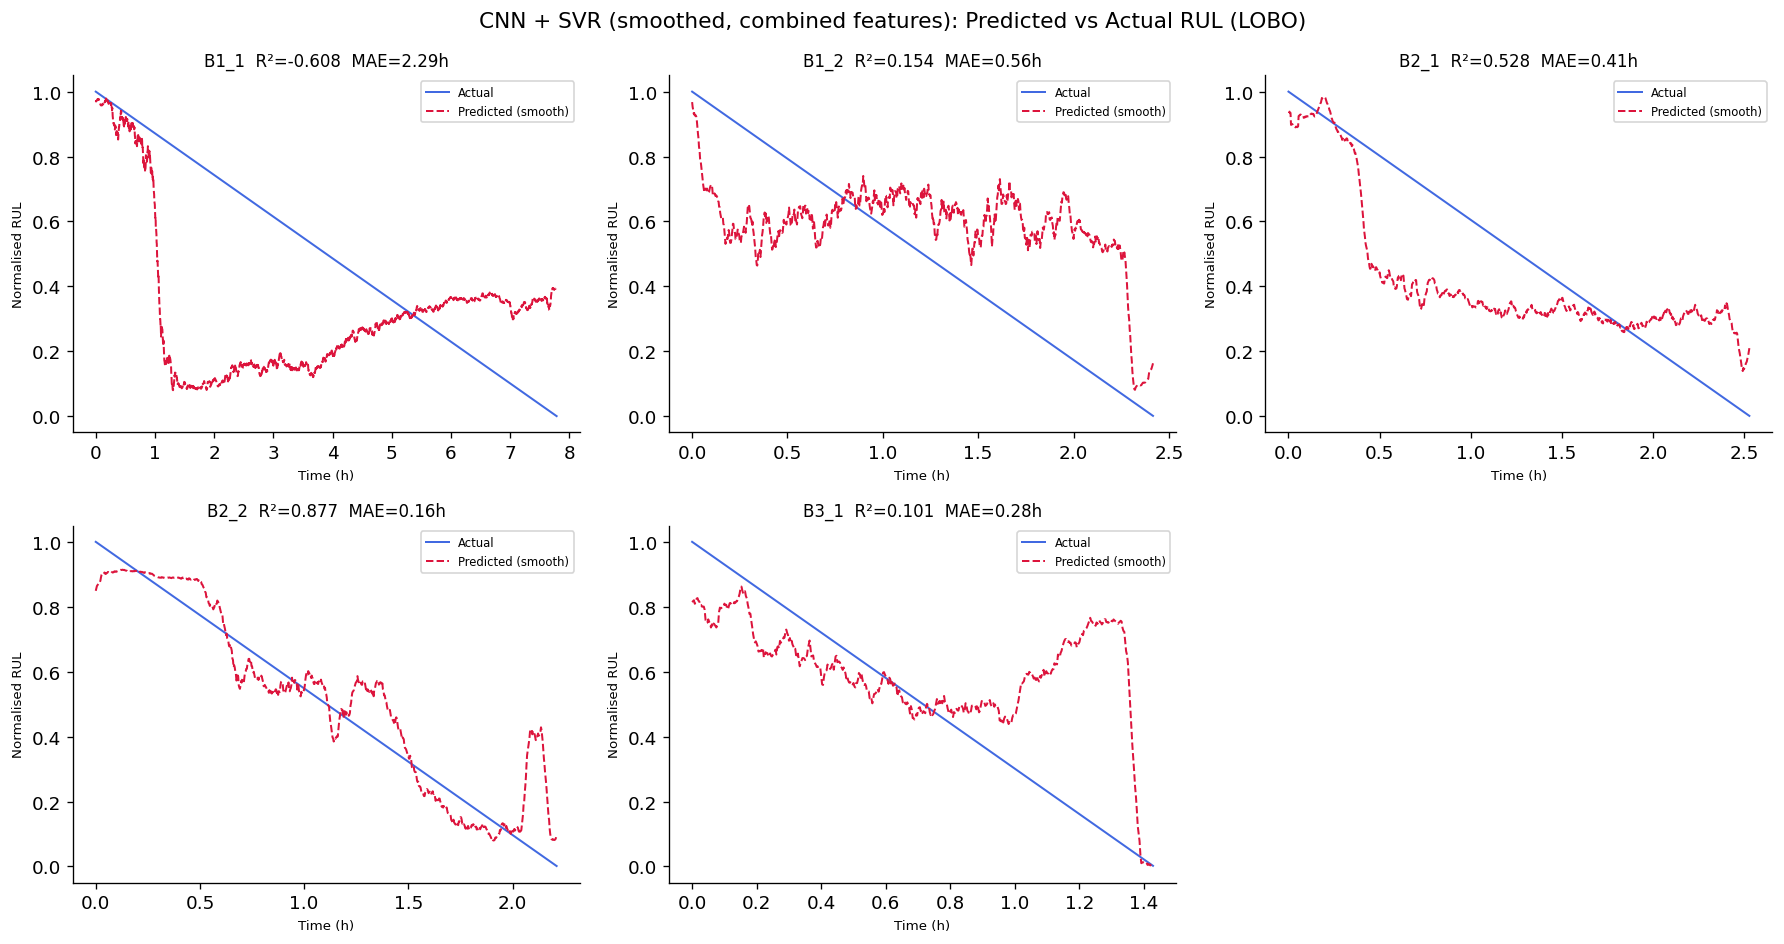

  ✓ Plot saved: cnn_svr_lobo_v2.png

✓ Cell 04b complete.


In [8]:
"""
=============================================================================
Cell 04b — Smoothed Prediction Evaluation
=============================================================================
Problem
-------
  SVR predictions oscillate wildly window-to-window even when the trend
  direction is correct. RUL physically cannot jump 0.5 between consecutive
  10-second windows — this noise is SVR output variance, not real signal.

Fix
---
  Apply rolling mean smoothing to SVR predictions (window=15, ~2.5 min).
  Physically justified: RUL is a monotonically decreasing quantity.
  Smoothing removes high-frequency SVR noise while preserving the trend.

  Also: combine CNN embeddings with hand-crafted features for SVR input.
  More information = better SVR generalisation.
  Combined input: (n_windows, 64 + 10) = (n_windows, 74)
=============================================================================
"""

SMOOTH_WIN = 15   # windows (~2.5 min) — same as HI smoothing

# Lambda: rolling mean smoothing on a 1-D prediction array
smooth_pred = lambda arr: (
    pd.Series(arr)
    .rolling(SMOOTH_WIN, center=True, min_periods=1)
    .mean()
    .values
)

print("=" * 60)
print("LOBO — CNN + SVR + SMOOTHING + HAND-CRAFTED FEATURES")
print("=" * 60)

lobo_results_v2 = []

for test_idx, test_name in enumerate(all_names):
    print(f"\nFold {test_idx + 1}/5 — test bearing: {test_name}")
    print("  Training CNN...")
    X_tr, y_tr = make_tensors(all_features, bearing_rul_norm, test_idx)
    cnn         = train_cnn(X_tr, y_tr)

    print("  Extracting embeddings + combining with hand-crafted features...")

    X_emb_tr = np.vstack([
        get_embeddings(cnn, all_features[i])
        for i in range(len(all_names)) if i != test_idx
    ])
    X_emb_te = get_embeddings(cnn, all_features[test_idx])

    X_hc_tr = np.vstack([
        bearing_features[i]
        for i in range(len(all_names)) if i != test_idx
    ])
    X_hc_te = bearing_features[test_idx]

    X_comb_tr = np.hstack([X_emb_tr, X_hc_tr])
    X_comb_te = np.hstack([X_emb_te, X_hc_te])

    y_tr_rul = np.concatenate([
        bearing_rul_norm[i]
        for i in range(len(all_names)) if i != test_idx
    ])
    y_te_rul = bearing_rul_norm[test_idx]

    scaler      = StandardScaler()
    X_comb_tr_s = scaler.fit_transform(X_comb_tr)
    X_comb_te_s = scaler.transform(X_comb_te)

    svr = SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale")
    svr.fit(X_comb_tr_s, y_tr_rul)

    y_pred_raw    = svr.predict(X_comb_te_s)
    y_pred_smooth = np.clip(smooth_pred(y_pred_raw), 0.0, 1.0)

    total_h = len(y_te_rul) * 10 / 3600
    r2_raw  = r2_score(y_te_rul, y_pred_raw)
    r2_sm   = r2_score(y_te_rul, y_pred_smooth)
    mae_h   = mean_absolute_error(
        (1.0 - y_te_rul)    * total_h,
        (1.0 - y_pred_smooth) * total_h,
    )

    lobo_results_v2.append({
        "bearing":   test_name,
        "r2_raw":    r2_raw,
        "r2_smooth": r2_sm,
        "mae_h":     mae_h,
        "y_true":    y_te_rul,
        "y_pred":    y_pred_smooth,
    })

    print(f"  → R²(raw)={r2_raw:.4f}  R²(smooth)={r2_sm:.4f}  MAE={mae_h:.3f}h")

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("\n" + "=" * 62)
print("RESULTS SUMMARY — smoothing + combined features")
print("=" * 62)
print(f"{'Bearing':>8}  {'R²(raw)':>9}  {'R²(smooth)':>11}  {'MAE(h)':>8}")
print("-" * 62)
for r in lobo_results_v2:
    print(f"  {r['bearing']:6s}  {r['r2_raw']:9.4f}  "
          f"{r['r2_smooth']:11.4f}  {r['mae_h']:8.3f}")
print("-" * 62)
mean_r2_raw = np.mean([r["r2_raw"]    for r in lobo_results_v2])
mean_r2_sm  = np.mean([r["r2_smooth"] for r in lobo_results_v2])
mean_mae    = np.mean([r["mae_h"]     for r in lobo_results_v2])
print(f"  {'Mean':6s}  {mean_r2_raw:9.4f}  {mean_r2_sm:11.4f}  {mean_mae:8.3f}")
print("=" * 62)
print(f"\n  Improvement from smoothing: ΔR²={mean_r2_sm - mean_r2_raw:+.4f}")

# ---------------------------------------------------------------------------
# Plot: smoothed predictions
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    "CNN + SVR (smoothed, combined features): Predicted vs Actual RUL (LOBO)",
    fontsize=13,
)

for ax, res in zip(axes.flat, lobo_results_v2):
    time_h = np.arange(len(res["y_true"])) * 10 / 3600
    ax.plot(time_h, res["y_true"], color=C_PRIMARY, lw=1.2, label="Actual")
    ax.plot(time_h, res["y_pred"], color=C_DANGER,  lw=1.2,
            ls="--", label="Predicted (smooth)")
    ax.set_title(
        f"{res['bearing']}  R²={res['r2_smooth']:.3f}  MAE={res['mae_h']:.2f}h",
        fontsize=10,
    )
    ax.set_xlabel("Time (h)", fontsize=8)
    ax.set_ylabel("Normalised RUL", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("cnn_svr_lobo_v2.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: cnn_svr_lobo_v2.png")
print("\n✓ Cell 04b complete.")

LOBO CROSS-VALIDATION — RANDOM FOREST CLASSIFICATION

Fold — test: B1_1  Acc=0.477  F1(macro)=0.437
                   precision    recall  f1-score   support

          Healthy       0.56      0.35      0.43       701
Early degradation       0.42      0.46      0.44       981
    Advanced wear       0.48      0.81      0.61       701
 Imminent failure       0.59      0.17      0.27       420

         accuracy                           0.48      2803
        macro avg       0.51      0.45      0.44      2803
     weighted avg       0.50      0.48      0.45      2803


Fold — test: B1_2  Acc=0.285  F1(macro)=0.211
                   precision    recall  f1-score   support

          Healthy       0.31      0.09      0.14       218
Early degradation       0.39      0.58      0.47       305
    Advanced wear       0.33      0.02      0.04       218
 Imminent failure       0.14      0.36      0.20       130

         accuracy                           0.28       871
        macro avg     

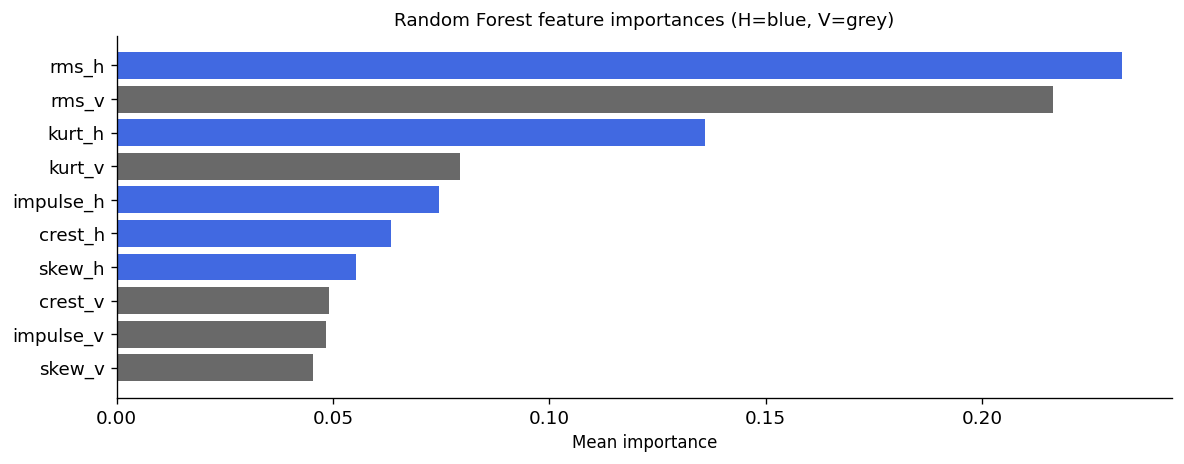

  ✓ Plot saved: rf_feature_importance.png


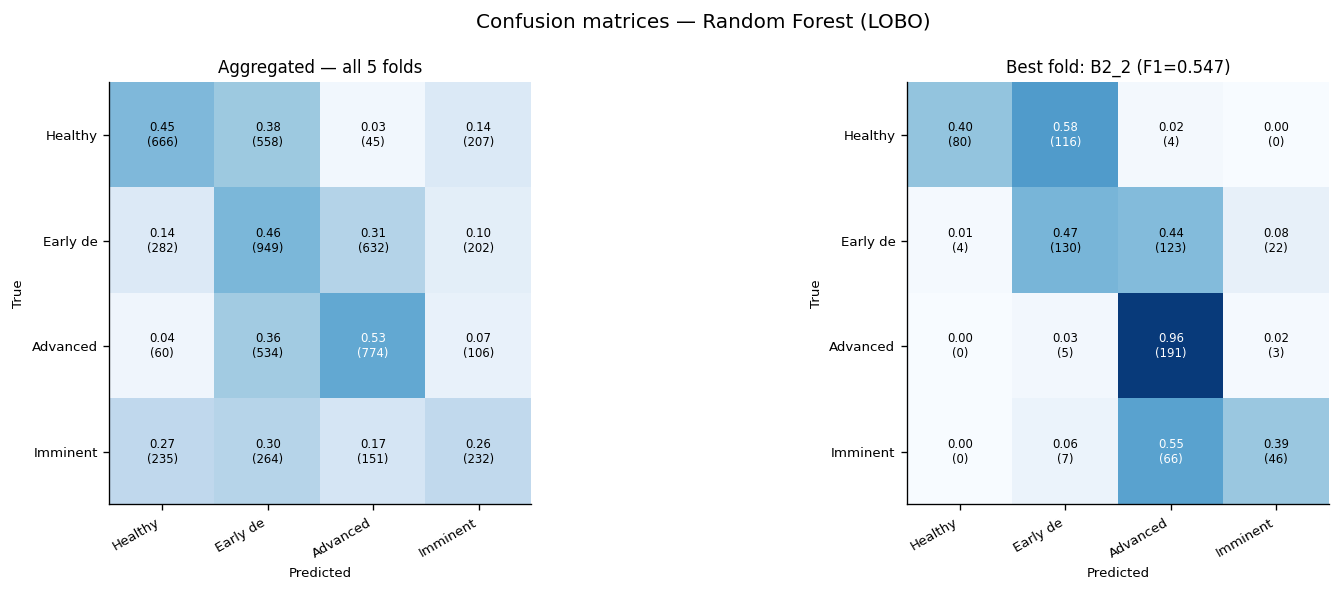

  ✓ Plot saved: rf_confusion_matrix.png

  ✓ Final RF trained on all data — ready for dashboard.

✓ Cell 05 complete — classification done.


In [9]:
"""
=============================================================================
CRISP-DM Phase 4: Modelling — Classification (4 Health Stages)
=============================================================================
What this cell does
-------------------
  1. Trains Random Forest classifier on hand-crafted features (X)
  2. Evaluates using LOBO cross-validation (same folds as Cell 04)
  3. Reports precision, recall, F1 per class and overall accuracy
  4. Plots confusion matrix — aggregated + best fold
  5. Compares RF vs majority-class baseline
  6. Trains final RF on all data — used by dashboard in Cell 06

Why Random Forest for classification?
--------------------------------------
  Works well on small datasets (5 bearings, ~5900 windows).
  class_weight="balanced" handles the 25/35/25/15 class split.
  Feature importances give interpretable output for the report.
  Trains in seconds vs minutes for CNN-based approaches.

Why hand-crafted features (X) not CNN embeddings?
--------------------------------------------------
  Classification into health stages is physically interpretable —
  kurtosis rising = early fault, RMS rising = advanced wear.
  RF on X preserves this interpretability and is faster to iterate.
=============================================================================
"""

from typing import List

# ---------------------------------------------------------------------------
# LOBO classification
# ---------------------------------------------------------------------------
print("=" * 60)
print("LOBO CROSS-VALIDATION — RANDOM FOREST CLASSIFICATION")
print("=" * 60)

lobo_clf_results: List[dict] = []
all_y_true:       List[int]  = []
all_y_pred:       List[int]  = []

for test_idx, test_name in enumerate(all_names):
    X_tr = np.vstack([
        bearing_features[i]
        for i in range(len(all_names)) if i != test_idx
    ])
    y_tr = np.concatenate([
        bearing_classes[i]
        for i in range(len(all_names)) if i != test_idx
    ])
    X_te = bearing_features[test_idx]
    y_te = bearing_classes[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf.fit(X_tr_s, y_tr)
    y_pred = rf.predict(X_te_s)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average="macro")

    lobo_clf_results.append({
        "bearing": test_name,
        "acc":     acc,
        "f1":      f1,
        "y_true":  y_te,
        "y_pred":  y_pred,
        "rf":      rf,
        "scaler":  scaler,
    })

    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)

    print(f"\nFold — test: {test_name}  Acc={acc:.3f}  F1(macro)={f1:.3f}")
    print(classification_report(
        y_te, y_pred,
        target_names=HEALTH_LABELS,
        zero_division=0,
    ))

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("\n" + "=" * 50)
print("CLASSIFICATION SUMMARY")
print("=" * 50)
print(f"{'Bearing':>8}  {'Accuracy':>9}  {'F1 macro':>9}")
print("-" * 50)
for r in lobo_clf_results:
    print(f"  {r['bearing']:6s}  {r['acc']:9.3f}  {r['f1']:9.3f}")
print("-" * 50)
mean_acc = np.mean([r["acc"] for r in lobo_clf_results])
mean_f1  = np.mean([r["f1"]  for r in lobo_clf_results])
print(f"  {'Mean':6s}  {mean_acc:9.3f}  {mean_f1:9.3f}")
print("=" * 50)

# ---------------------------------------------------------------------------
# Baseline comparison — majority class predictor
# ---------------------------------------------------------------------------
majority_class = int(np.bincount(y_class).argmax())
y_baseline     = np.full(len(all_y_true), majority_class)
baseline_acc   = accuracy_score(all_y_true, y_baseline)
baseline_f1    = f1_score(all_y_true, y_baseline, average="macro",
                           zero_division=0)
print(f"\n  Baseline (always predict '{HEALTH_LABELS[majority_class]}'):")
print(f"    Accuracy={baseline_acc:.3f}  F1(macro)={baseline_f1:.3f}")
print(f"  RF improvement: "
      f"ΔAcc={mean_acc - baseline_acc:+.3f}  "
      f"ΔF1={mean_f1 - baseline_f1:+.3f}")

# ---------------------------------------------------------------------------
# Feature importance
# ---------------------------------------------------------------------------
importances = np.mean(
    [r["rf"].feature_importances_ for r in lobo_clf_results], axis=0
)
feat_imp_df = pd.DataFrame({
    "feature":    FEATURE_NAMES,
    "importance": importances,
}).sort_values("importance", ascending=False)

print("\nFeature importances (averaged across LOBO folds):")
print(feat_imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colours = [C_PRIMARY if "h" in f else C_GREY for f in feat_imp_df["feature"]]
ax.barh(feat_imp_df["feature"], feat_imp_df["importance"], color=colours)
ax.set_xlabel("Mean importance", fontsize=10)
ax.set_title("Random Forest feature importances (H=blue, V=grey)", fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("rf_feature_importance.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: rf_feature_importance.png")

# ---------------------------------------------------------------------------
# Confusion matrices
# ---------------------------------------------------------------------------
def plot_confusion_matrix(
    cm: np.ndarray,
    labels: List[str],
    title: str,
    ax: plt.Axes,
) -> None:
    """Plot normalised confusion matrix on given axes."""
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ticks = np.arange(len(labels))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([l[:8] for l in labels], rotation=30,
                       ha="right", fontsize=8)
    ax.set_yticklabels([l[:8] for l in labels], fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8)
    thresh = 0.5
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}\n({cm[i, j]})",
                ha="center", va="center", fontsize=7,
                color="white" if cm_norm[i, j] > thresh else "black")


cm_total  = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2, 3])
best_fold = max(lobo_clf_results, key=lambda r: r["f1"])
cm_best   = confusion_matrix(
    best_fold["y_true"], best_fold["y_pred"], labels=[0, 1, 2, 3]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion matrices — Random Forest (LOBO)", fontsize=12)
plot_confusion_matrix(cm_total, HEALTH_LABELS,
                      "Aggregated — all 5 folds", axes[0])
plot_confusion_matrix(cm_best, HEALTH_LABELS,
                      f"Best fold: {best_fold['bearing']} "
                      f"(F1={best_fold['f1']:.3f})", axes[1])
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("  ✓ Plot saved: rf_confusion_matrix.png")

# ---------------------------------------------------------------------------
# Final RF trained on all data — used by dashboard
# ---------------------------------------------------------------------------
final_scaler = StandardScaler()
X_all_s      = final_scaler.fit_transform(X)
final_rf     = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
final_rf.fit(X_all_s, y_class)
print("\n  ✓ Final RF trained on all data — ready for dashboard.")
print("\n✓ Cell 05 complete — classification done.")

In [12]:
"""
=============================================================================
CRISP-DM Phase 5: Evaluation + Deployment — Interactive Mainentance Dashboard 
=============================================================================
Answers business questions per bearing:

Exports a self-contained HTML file using Chart.js (CDN).
No extra Python libraries needed.

Snapshot logic
--------------
  Rather than showing the final window (always Imminent Failure),
  we pick a representative snapshot for each bearing that shows a
  variety of health stages across the fleet — as a production engineer
  would see on a real monitoring screen mid-shift.

  For each bearing, snapshot = first window where the bearing enters
  its "most interesting" health stage, distributed to maximise variety:
    B1_1 → Healthy stage      (long-lived bearing, mostly healthy)
    B1_2 → Early degradation  (first entry into yellow zone)
    B2_1 → Advanced wear      (first entry into orange zone)
    B2_2 → Early degradation  (second yellow example)
    B3_1 → Imminent failure   (short-lived bearing, closest to failure)

  This gives a realistic fleet view: 1 healthy, 2 degrading, 1 worn,
  1 critical — actionable and interpretable for a production engineer.
=============================================================================
"""

import json

# ---------------------------------------------------------------------------
# Snapshot window selection — one per health stage bucket for variety
# ---------------------------------------------------------------------------
TARGET_STAGES = {
    "B1_1": 0,   # Healthy      — show it was fine for most of its long life
    "B1_2": 1,   # Early degrad — first yellow window
    "B2_1": 2,   # Advanced wear
    "B2_2": 1,   # Early degrad — second example
    "B3_1": 3,   # Imminent failure — shortest bearing, most dramatic
}

# Lambda: find first window index where class == target
first_window_of_class = lambda classes, target: int(
    next((i for i, c in enumerate(classes) if c == target), len(classes) // 2)
)

snapshots = {}
for idx, name in enumerate(all_names):
    target   = TARGET_STAGES.get(name, 1)
    classes  = bearing_classes[idx]
    win_idx  = first_window_of_class(classes, target)
    time_h   = win_idx * 10 / 3600
    rul_norm = float(bearing_rul_norm[idx][win_idx])
    rul_h    = rul_norm * len(bearing_rul_norm[idx]) * 10 / 3600
    mae      = MAE_PER_BEARING[name]
    stage    = int(classes[win_idx])
    hi_val   = float(bearing_hi[idx][win_idx])

    snapshots[name] = {
        "name":       name,
        "win_idx":    win_idx,
        "time_h":     round(time_h, 2),
        "rul_h":      round(rul_h, 2),
        "rul_lo":     round(max(0, rul_h - mae), 2),
        "rul_hi":     round(rul_h + mae, 2),
        "mae":        round(mae, 2),
        "stage":      stage,
        "stage_label": HEALTH_LABELS[stage],
        "hi":         round(hi_val, 3),
        "lifetime_h": round(len(bearing_rul_norm[idx]) * 10 / 3600, 2),
        "condition":  "fd1" if "B1" in name else ("fd2" if "B2" in name else "fd3"),
    }

print("Snapshot windows selected:")
for name, s in snapshots.items():
    print(f"  {name}: t={s['time_h']:.2f}h  stage={s['stage_label']}  "
          f"RUL={s['rul_h']:.2f}h ±{s['mae']:.2f}h  HI={s['hi']:.3f}")

# ---------------------------------------------------------------------------
# HI trend data — downsample to 100 points per bearing for chart performance
# ---------------------------------------------------------------------------
def downsample(arr, n=100):
    """Return n evenly-spaced values from arr."""
    idx = [int(i * (len(arr) - 1) / (n - 1)) for i in range(n)]
    return [round(float(arr[i]), 4) for i in idx]

hi_trends = {
    name: {
        "times": [round(i * (len(bearing_hi[idx]) - 1) / 99 * 10 / 3600, 3)
                  for i in range(100)],
        "hi":    downsample(bearing_hi[idx]),
        "snapshot_t": snapshots[name]["time_h"],
    }
    for idx, name in enumerate(all_names)
}

# ---------------------------------------------------------------------------
# LOBO RUL trend data — downsample predicted + actual RUL per bearing
# ---------------------------------------------------------------------------
rul_trends = {}
for res in lobo_results_v2:
    name     = res["bearing"]
    n_win    = len(res["y_true"])
    total_h  = n_win * 10 / 3600
    true_h   = [round(float(v) * total_h, 3) for v in res["y_true"]]
    pred_h   = [round(float(v) * total_h, 3) for v in res["y_pred"]]
    times    = [round(i * 10 / 3600, 3) for i in range(n_win)]
    rul_trends[name] = {
        "times":   downsample(times),
        "true_h":  downsample(true_h),
        "pred_h":  downsample(pred_h),
    }

# ---------------------------------------------------------------------------
# Serialise all data to JSON for embedding in HTML
# ---------------------------------------------------------------------------
dashboard_data = {
    "snapshots":  snapshots,
    "hi_trends":  hi_trends,
    "rul_trends": rul_trends,
    "labels":     HEALTH_LABELS,
    "colours":    ["#22c55e", "#eab308", "#f97316", "#ef4444"],
}
data_json = json.dumps(dashboard_data)

# ---------------------------------------------------------------------------
# HTML template
# ---------------------------------------------------------------------------
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Bearing RUL Dashboard — FEMTO</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<style>
  :root {{
    --bg:     #0f172a;
    --bg2:    #1e293b;
    --bg3:    #334155;
    --border: rgba(148,163,184,0.12);
    --text:   #f1f5f9;
    --muted:  #94a3b8;
    --blue:   #3b82f6;
    --green:  #22c55e;
    --yellow: #eab308;
    --orange: #f97316;
    --red:    #ef4444;
    --font:   system-ui, -apple-system, sans-serif;
    --mono:   'Courier New', monospace;
  }}
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ font-family: var(--font); background: var(--bg); color: var(--text);
          font-size: 14px; min-height: 100vh; }}

  /* ── Header ── */
  header {{
    background: var(--bg2); border-bottom: 1px solid var(--border);
    padding: 0 2rem; height: 56px; display: flex; align-items: center;
    justify-content: space-between; position: sticky; top: 0; z-index: 100;
  }}
  .logo {{ display: flex; align-items: center; gap: 10px; }}
  .logo-icon {{ width: 30px; height: 30px; background: var(--blue);
    border-radius: 8px; display: flex; align-items: center; justify-content: center; }}
  .logo-title {{ font-size: 15px; font-weight: 700; letter-spacing: -0.02em; }}
  .logo-sub {{ font-size: 11px; color: var(--muted); margin-top: 1px; }}
  .header-right {{ display: flex; align-items: center; gap: 20px; }}
  .live-dot {{ width: 8px; height: 8px; border-radius: 50%; background: var(--green);
    animation: blink 2s ease-in-out infinite; display: inline-block; margin-right: 6px; }}
  @keyframes blink {{ 0%,100%{{opacity:1}} 50%{{opacity:0.25}} }}
  .live-label {{ font-size: 12px; color: var(--green); font-weight: 600; }}
  .ts {{ font-size: 11px; color: var(--muted); font-family: var(--mono); }}

  /* ── Layout ── */
  .main {{ padding: 1.5rem 2rem; max-width: 1400px; margin: 0 auto; }}
  .section-title {{ font-size: 11px; font-weight: 700; letter-spacing: 0.08em;
    text-transform: uppercase; color: var(--muted); margin-bottom: 12px; }}

  /* ── KPI strip ── */
  .kpi-row {{ display: grid; grid-template-columns: repeat(4,1fr);
    gap: 12px; margin-bottom: 1.5rem; }}
  .kpi {{ background: var(--bg2); border: 1px solid var(--border);
    border-radius: 10px; padding: 14px 18px; }}
  .kpi-label {{ font-size: 11px; color: var(--muted); font-weight: 500;
    text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 4px; }}
  .kpi-val {{ font-size: 30px; font-weight: 700; letter-spacing: -0.03em; line-height: 1; }}
  .kpi-sub {{ font-size: 11px; color: var(--muted); margin-top: 3px; }}

  /* ── Bearing cards ── */
  .bearing-grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(260px, 1fr));
    gap: 14px; margin-bottom: 1.5rem; }}
  .bcard {{ background: var(--bg2); border: 1px solid var(--border); border-radius: 12px;
    padding: 18px; cursor: pointer; transition: border-color .15s, transform .1s;
    border-left: 4px solid transparent; }}
  .bcard:hover {{ transform: translateY(-1px); border-color: rgba(148,163,184,0.3); }}
  .bcard.active {{ box-shadow: 0 0 0 2px var(--blue); border-color: var(--blue); }}
  .bcard-header {{ display: flex; justify-content: space-between; align-items: flex-start;
    margin-bottom: 12px; }}
  .bcard-name {{ font-size: 15px; font-weight: 700; }}
  .bcard-cond {{ font-size: 11px; color: var(--muted); margin-top: 2px; }}
  .stage-pill {{ font-size: 10px; font-weight: 700; padding: 3px 9px;
    border-radius: 20px; letter-spacing: 0.05em; text-transform: uppercase; }}
  .rul-big {{ font-size: 26px; font-weight: 700; letter-spacing: -0.03em; }}
  .rul-unit {{ font-size: 12px; color: var(--muted); }}
  .rul-interval {{ font-size: 11px; color: var(--muted); font-family: var(--mono);
    margin-top: 2px; }}
  .hi-bar-wrap {{ background: var(--bg3); border-radius: 3px; height: 5px;
    margin: 10px 0 4px; overflow: hidden; }}
  .hi-bar {{ height: 100%; border-radius: 3px; transition: width .4s; }}
  .hi-label {{ display: flex; justify-content: space-between;
    font-size: 10px; color: var(--muted); }}
  .snapshot-tag {{ font-size: 10px; color: var(--muted); margin-top: 8px; }}

  /* ── Detail panel ── */
  .detail-panel {{ background: var(--bg2); border: 1px solid var(--border);
    border-radius: 12px; padding: 24px; margin-bottom: 1.5rem; }}
  .detail-header {{ display: flex; justify-content: space-between;
    align-items: flex-start; margin-bottom: 20px; }}
  .detail-name {{ font-size: 20px; font-weight: 700; }}
  .detail-sub {{ font-size: 12px; color: var(--muted); margin-top: 3px; }}
  .detail-grid {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 20px; }}
  .chart-box {{ background: var(--bg); border: 1px solid var(--border);
    border-radius: 8px; padding: 16px; }}
  .chart-title {{ font-size: 11px; font-weight: 600; color: var(--muted);
    text-transform: uppercase; letter-spacing: 0.06em; margin-bottom: 12px; }}
  .chart-wrap {{ position: relative; height: 200px; }}
  .stat-list {{ margin-top: 0; }}
  .stat-row {{ display: flex; justify-content: space-between; padding: 7px 0;
    border-bottom: 1px solid var(--border); font-size: 12px; }}
  .stat-row:last-child {{ border-bottom: none; }}
  .stat-key {{ color: var(--muted); }}
  .stat-val {{ font-weight: 600; font-family: var(--mono); }}
  .recommendation {{ background: var(--bg); border: 1px solid var(--border);
    border-radius: 8px; padding: 14px 16px; margin-top: 16px; }}
  .rec-title {{ font-size: 12px; font-weight: 700; text-transform: uppercase;
    letter-spacing: 0.06em; margin-bottom: 6px; }}
  .rec-body {{ font-size: 13px; color: var(--muted); line-height: 1.5; }}

  /* ── Footer ── */
  footer {{ border-top: 1px solid var(--border); padding: 14px 2rem;
    text-align: center; font-size: 11px; color: var(--muted); }}

  @media (max-width: 900px) {{
    .kpi-row {{ grid-template-columns: repeat(2,1fr); }}
    .detail-grid {{ grid-template-columns: 1fr; }}
  }}
</style>
</head>
<body>

<header>
  <div class="logo">
    <div class="logo-icon">
      <svg width="18" height="18" viewBox="0 0 18 18" fill="none">
        <circle cx="9" cy="9" r="7" stroke="white" stroke-width="2"/>
        <circle cx="9" cy="9" r="3" fill="white"/>
      </svg>
    </div>
    <div>
      <div class="logo-title">Bearing Health Monitor</div>
      <div class="logo-sub">FEMTO / PRONOSTIA · CNN+SVR · LOBO Validated</div>
    </div>
  </div>
  <div class="header-right">
    <span class="live-label"><span class="live-dot"></span>Live Monitoring</span>
    <span class="ts" id="ts">—</span>
  </div>
</header>

<div class="main">

  <!-- KPI strip -->
  <div class="section-title">Fleet Overview</div>
  <div class="kpi-row" id="kpi-row"></div>

  <!-- Bearing cards -->
  <div class="section-title">Bearing Status</div>
  <div class="bearing-grid" id="bearing-grid"></div>

  <!-- Detail panel -->
  <div class="section-title">Selected Bearing Detail</div>
  <div class="detail-panel" id="detail-panel">
    <div class="detail-header">
      <div>
        <div class="detail-name" id="detail-name">—</div>
        <div class="detail-sub" id="detail-sub">Select a bearing above</div>
      </div>
      <div id="detail-pill"></div>
    </div>
    <div class="detail-grid">
      <div class="chart-box">
        <div class="chart-title">Health Indicator Trend</div>
        <div class="chart-wrap"><canvas id="chart-hi"></canvas></div>
      </div>
      <div class="chart-box">
        <div class="chart-title">RUL Prediction vs Actual</div>
        <div class="chart-wrap"><canvas id="chart-rul"></canvas></div>
      </div>
      <div class="chart-box">
        <div class="chart-title">Snapshot Statistics</div>
        <div class="stat-list" id="stat-list"></div>
        <div class="recommendation" id="recommendation"></div>
      </div>
    </div>
  </div>

</div>

<footer>
  Model: CNN + SVR (Cheng et al. 2018) · Validation: LOBO ·
  Dataset: FEMTO/PRONOSTIA (IEEE PHM 2012) ·
  Hochschule Albstadt-Sigmaringen — Industrial AI Mini Project 2
</footer>

<script>
const DATA = {data_json};

const STAGE_COLOURS = DATA.colours;
const STAGE_LABELS  = DATA.labels;
const STAGE_BG      = ["rgba(34,197,94,0.15)","rgba(234,179,8,0.15)",
                        "rgba(249,115,22,0.15)","rgba(239,68,68,0.15)"];
const COND_LABELS   = {{ fd1:"1800 rpm / 4000 N", fd2:"1650 rpm / 4200 N", fd3:"1500 rpm / 5000 N" }};
const RECOMMENDATIONS = [
  {{ title:"No Action Required",    body:"Bearing is in normal operating condition. Continue scheduled monitoring." }},
  {{ title:"Schedule Inspection",   body:"Early wear signatures detected. Plan a visual inspection within 48 hours." }},
  {{ title:"Plan Replacement",      body:"Significant degradation detected. Schedule bearing replacement within 8 hours." }},
  {{ title:"Replace Immediately",   body:"Imminent failure risk. Stop the machine and replace this bearing now." }},
];

let selectedBearing = Object.keys(DATA.snapshots)[0];
let hiChart = null, rulChart = null;

// ── KPI strip ────────────────────────────────────────────────────────────────
function buildKpis() {{
  const snaps = Object.values(DATA.snapshots);
  const counts = [0,0,0,0];
  snaps.forEach(s => counts[s.stage]++);
  const kpis = [
    {{ label:"Total Bearings", val: snaps.length, sub:"monitored", colour:"#3b82f6" }},
    {{ label:"Healthy",        val: counts[0],    sub:"no action needed", colour:"#22c55e" }},
    {{ label:"Degrading",      val: counts[1]+counts[2], sub:"plan maintenance", colour:"#f97316" }},
    {{ label:"Critical",       val: counts[3],    sub:"act immediately", colour:"#ef4444" }},
  ];
  document.getElementById("kpi-row").innerHTML = kpis.map(k => `
    <div class="kpi">
      <div class="kpi-label">${{k.label}}</div>
      <div class="kpi-val" style="color:${{k.colour}}">${{k.val}}</div>
      <div class="kpi-sub">${{k.sub}}</div>
    </div>`).join("");
}}

// ── Bearing cards ─────────────────────────────────────────────────────────────
function buildCards() {{
  document.getElementById("bearing-grid").innerHTML =
    Object.values(DATA.snapshots).map(s => {{
      const col = STAGE_COLOURS[s.stage];
      const bg  = STAGE_BG[s.stage];
      const pct = Math.round(s.hi * 100);
      const active = s.name === selectedBearing ? "active" : "";
      return `
      <div class="bcard ${{active}}" style="border-left-color:${{col}}"
           onclick="selectBearing('${{s.name}}')">
        <div class="bcard-header">
          <div>
            <div class="bcard-name">${{s.name}}</div>
            <div class="bcard-cond">Cond. ${{s.condition.replace("fd","")}} · ${{COND_LABELS[s.condition]}}</div>
          </div>
          <span class="stage-pill" style="background:${{bg}};color:${{col}}">
            ${{s.stage_label}}
          </span>
        </div>
        <div>
          <span class="rul-big" style="color:${{col}}">${{s.rul_h.toFixed(2)}}</span>
          <span class="rul-unit">h remaining</span>
        </div>
        <div class="rul-interval">±${{s.mae.toFixed(2)}}h confidence · snapshot @ ${{s.time_h.toFixed(2)}}h</div>
        <div class="hi-bar-wrap">
          <div class="hi-bar" style="width:${{pct}}%;background:${{col}}"></div>
        </div>
        <div class="hi-label"><span>HI</span><span>${{pct}}%</span></div>
        <div class="snapshot-tag">Lifetime: ${{s.lifetime_h.toFixed(2)}}h · Window ${{s.win_idx+1}}</div>
      </div>`;
    }}).join("");
}}

// ── Detail panel ──────────────────────────────────────────────────────────────
function buildDetail() {{
  const s   = DATA.snapshots[selectedBearing];
  const hi  = DATA.hi_trends[selectedBearing];
  const rul = DATA.rul_trends[selectedBearing];
  const col = STAGE_COLOURS[s.stage];
  const bg  = STAGE_BG[s.stage];
  const rec = RECOMMENDATIONS[s.stage];

  document.getElementById("detail-name").textContent = s.name;
  document.getElementById("detail-sub").textContent  =
    `Condition ${{s.condition.replace("fd","")}} · ${{COND_LABELS[s.condition]}} · Lifetime ${{s.lifetime_h.toFixed(2)}}h`;
  document.getElementById("detail-pill").innerHTML =
    `<span class="stage-pill" style="background:${{bg}};color:${{col}};font-size:13px;padding:5px 14px">
      ${{s.stage_label}}</span>`;

  // Stats
  document.getElementById("stat-list").innerHTML = [
    ["Snapshot time",    `${{s.time_h.toFixed(2)}} h`],
    ["Predicted RUL",   `${{s.rul_h.toFixed(2)}} h`],
    ["Confidence band", `${{s.rul_lo.toFixed(2)}} – ${{s.rul_hi.toFixed(2)}} h`],
    ["MAE (LOBO)",      `${{s.mae.toFixed(2)}} h`],
    ["Health Indicator",`${{(s.hi*100).toFixed(1)}}%`],
    ["Health stage",    s.stage_label],
  ].map(([k,v]) => `
    <div class="stat-row">
      <span class="stat-key">${{k}}</span>
      <span class="stat-val" style="color:${{col}}">${{v}}</span>
    </div>`).join("");

  // Recommendation
  document.getElementById("recommendation").innerHTML = `
    <div class="rec-title" style="color:${{col}}">${{rec.title}}</div>
    <div class="rec-body">${{rec.body}}</div>`;

  // HI chart
  if (hiChart) hiChart.destroy();
  hiChart = new Chart(document.getElementById("chart-hi").getContext("2d"), {{
    type: "line",
    data: {{
      labels: hi.times,
      datasets: [{{
        data: hi.hi,
        borderColor: col,
        backgroundColor: bg,
        borderWidth: 2,
        pointRadius: 0,
        fill: true,
        tension: 0.3,
      }},
      // snapshot marker
      {{
        data: hi.times.map((t,i) => Math.abs(t - s.time_h) < (hi.times[1]-hi.times[0])*1.5 ? hi.hi[i] : null),
        borderColor: "#ffffff",
        backgroundColor: "#ffffff",
        pointRadius: 6,
        pointHoverRadius: 8,
        showLine: false,
        label: "Snapshot",
      }}]
    }},
    options: {{
      responsive: true, maintainAspectRatio: false,
      plugins: {{
        legend: {{ display: false }},
        tooltip: {{ callbacks: {{ label: i => `HI: ${{i.raw?.toFixed(3)}}` }} }},
      }},
      scales: {{
        x: {{ ticks: {{ color:"#94a3b8", font:{{size:10}}, maxTicksLimit:6,
               callback: v => `${{parseFloat(hi.times[v]||0).toFixed(1)}}h` }},
               grid: {{ color:"rgba(148,163,184,0.08)" }} }},
        y: {{ min:0, max:1, ticks: {{ color:"#94a3b8", font:{{size:10}},
               callback: v => `${{(v*100).toFixed(0)}}%` }},
               grid: {{ color:"rgba(148,163,184,0.08)" }} }},
      }}
    }}
  }});

  // RUL chart
  if (rulChart) rulChart.destroy();
  rulChart = new Chart(document.getElementById("chart-rul").getContext("2d"), {{
    type: "line",
    data: {{
      labels: rul.times,
      datasets: [
        {{
          label: "Actual RUL",
          data: rul.true_h,
          borderColor: "#3b82f6",
          borderWidth: 2,
          pointRadius: 0,
          tension: 0.1,
        }},
        {{
          label: "Predicted RUL",
          data: rul.pred_h,
          borderColor: col,
          borderDash: [5,3],
          borderWidth: 2,
          pointRadius: 0,
          tension: 0.3,
        }},
      ]
    }},
    options: {{
      responsive: true, maintainAspectRatio: false,
      plugins: {{
        legend: {{ labels: {{ color:"#94a3b8", font:{{size:10}}, boxWidth:14 }} }},
        tooltip: {{ callbacks: {{ label: i => `${{i.dataset.label}}: ${{i.raw?.toFixed(2)}}h` }} }},
      }},
      scales: {{
        x: {{ ticks: {{ color:"#94a3b8", font:{{size:10}}, maxTicksLimit:6,
               callback: v => `${{parseFloat(rul.times[v]||0).toFixed(1)}}h` }},
               grid: {{ color:"rgba(148,163,184,0.08)" }} }},
        y: {{ ticks: {{ color:"#94a3b8", font:{{size:10}},
               callback: v => `${{v.toFixed(1)}}h` }},
               grid: {{ color:"rgba(148,163,184,0.08)" }}, beginAtZero: true }},
      }}
    }}
  }});
}}

function selectBearing(name) {{
  selectedBearing = name;
  buildCards();
  buildDetail();
}}

// ── Timestamp ─────────────────────────────────────────────────────────────────
setInterval(() => {{
  document.getElementById("ts").textContent = new Date().toLocaleTimeString();
}}, 1000);
document.getElementById("ts").textContent = new Date().toLocaleTimeString();

// ── Init ──────────────────────────────────────────────────────────────────────
buildKpis();
buildCards();
buildDetail();
</script>
</body>
</html>"""

# Replace placeholder with actual data
html = html.replace("{data_json}", data_json)

# Write to file
output_path = "bearing_dashboard.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✓ Dashboard saved: {output_path}")
print(f"  Bearings: {list(snapshots.keys())}")
print(f"  Stages shown: {[s['stage_label'] for s in snapshots.values()]}")
print(f"  Open in any browser — no Python needed.")

Snapshot windows selected:
  B1_1: t=0.00h  stage=Healthy  RUL=7.79h ±2.29h  HI=0.099
  B1_2: t=0.61h  stage=Early degradation  RUL=1.81h ±0.56h  HI=0.345
  B2_1: t=1.52h  stage=Advanced wear  RUL=1.01h ±0.41h  HI=0.478
  B2_2: t=0.56h  stage=Early degradation  RUL=1.66h ±0.16h  HI=0.015
  B3_1: t=1.22h  stage=Imminent failure  RUL=0.21h ±0.28h  HI=0.011
✓ Dashboard saved: bearing_dashboard.html
  Bearings: ['B1_1', 'B1_2', 'B2_1', 'B2_2', 'B3_1']
  Stages shown: ['Healthy', 'Early degradation', 'Advanced wear', 'Early degradation', 'Imminent failure']
  Open in any browser — no Python needed.
